In [1]:
import pandas as pd
import numpy as np
import re

from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
from pathlib import Path

BASE = Path(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13"
)

RUTA_ARTICULOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "prensa"
    / "articulos_con_texto"
)

RUTA_FINAL_PRENSA = (
    BASE
    / "01_data"
    / "03_final"
    / "prensa"
)

RUTA_MODELOS = (
    BASE
    / "01_data"
    / "02_processed"
    / "modelos"
)

RUTA_TABLAS_PRENSA = (
    BASE
    / "03_outputs"
    / "tables"
    / "prensa"
)

RUTA_TABLAS_INTEGRADO = (
    BASE
    / "03_outputs"
    / "tables"
    / "analisis_integrado"
)

RUTA_FIGURAS_PRENSA = (
    BASE
    / "03_outputs"
    / "figures"
    / "prensa"
)


# Carpetas generales de BERTopic
RUTA_BERTOPIC_TABLAS = (
    RUTA_TABLAS_PRENSA
    / "bertopic"
)

RUTA_BERTOPIC_FIGURAS = (
    RUTA_FIGURAS_PRENSA
    / "bertopic"
)

# Carpetas BERTopic por temática
RUTA_BERTOPIC_INMIGRACION_TABLAS = (
    RUTA_BERTOPIC_TABLAS
    / "inmigracion"
)

RUTA_BERTOPIC_LGTBI_TABLAS = (
    RUTA_BERTOPIC_TABLAS
    / "lgtbi"
)

RUTA_BERTOPIC_INMIGRACION_FIGURAS = (
    RUTA_BERTOPIC_FIGURAS
    / "inmigracion"
)

RUTA_BERTOPIC_LGTBI_FIGURAS = (
    RUTA_BERTOPIC_FIGURAS
    / "lgtbi"
)

# Crear las carpetas si no existen
for ruta in [
    RUTA_BERTOPIC_INMIGRACION_TABLAS,
    RUTA_BERTOPIC_LGTBI_TABLAS,
    RUTA_BERTOPIC_INMIGRACION_FIGURAS,
    RUTA_BERTOPIC_LGTBI_FIGURAS,
]:
    ruta.mkdir(parents=True, exist_ok=True)

archivos = sorted(
    RUTA_ARTICULOS.glob("*_con_texto.csv")
)

RUTA_FIGURAS_TRIGRAMAS = (
    RUTA_FIGURAS_PRENSA
    / "trigramas"
)

RUTA_FIGURAS_TRIGRAMAS.mkdir(
    parents=True,
    exist_ok=True
)


In [3]:
print(f"Archivos encontrados: {len(archivos)}")

if not archivos:
    raise FileNotFoundError(
        f"No se encontraron archivos en: {RUTA_ARTICULOS}"
    )

dfs = []

for archivo in archivos:

    df_archivo = pd.read_csv(archivo)
    nombre = archivo.name.lower()

    # Obtener el tema del nombre del archivo
    if nombre.startswith("inmigracion_"):
        df_archivo["tema"] = "inmigracion"

    elif nombre.startswith("lgtb_"):
        df_archivo["tema"] = "lgtb"

    else:
        raise ValueError(
            f"No se reconoce el tema de: {archivo.name}"
        )

    # El notebook utiliza year_dataset
    if (
        "anio" in df_archivo.columns
        and "year_dataset" not in df_archivo.columns
    ):
        df_archivo = df_archivo.rename(
            columns={"anio": "year_dataset"}
        )

    dfs.append(df_archivo)

df_prensa = pd.concat(
    dfs,
    ignore_index=True
)

print("Dimensiones:", df_prensa.shape)

print("\nTemas:")
print(df_prensa["tema"].value_counts())

print("\nAños:")
print(
    df_prensa["year_dataset"]
    .value_counts()
    .sort_index()
)

Archivos encontrados: 8
Dimensiones: (94042, 11)

Temas:
tema
inmigracion    71470
lgtb           22572
Name: count, dtype: int64

Años:
year_dataset
2015    17074
2016    19245
2019    26815
2023    30908
Name: count, dtype: int64


In [4]:
df_nlp = df_prensa[
    df_prensa["texto"].notna()
].copy()

print(df_nlp.shape)

(75151, 11)


In [5]:
def limpiar_texto(texto):

    texto = texto.lower()

    texto = re.sub(r"http\S+", " ", texto)

    texto = re.sub(r"\n", " ", texto)

    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [6]:
df_nlp["texto_limpio"] = (
    df_nlp["texto"]
    .apply(limpiar_texto)
)

In [7]:
df_nlp[
    ["title", "texto_limpio"]
].head(3)

,title,texto_limpio
0,Golpe a la inmigraciÃ³n clandestina,golpe a la inmigración clandestina contra los ...
1,Los Reyes Magos van en patera,los reyes magos van en patera aquellos vetusto...
2,Cae de manera drÃ¡stica la contrataciÃ³n de in...,cae de manera drástica la contratación de inmi...


In [8]:
df_nlp["title"].sample(20).tolist()

['Gastos por cirugías a militares transgénero en los EEUU provoca polémica',
 'Alcaraz (Vox) impide que el Senado apruebe una Declaración Institucional en contra de la LGTBIfobia en el deporte',
 'El Open Arms cumple una semana con 121 migrantes rescatados y a la espera de puerto seguro',
 'Podemos propone abrir en San Lorenzo de El Escorial un museo de temática LGTBI',
 'Colectivos migrantes y antirracistas preparan una jornada de lucha por la regularización en Canadá',
 'La Guardia Civil rescata a 22 inmigrantes en una patera',
 'Barcelona acusa a la Generalitat de “chupar rueda” en política de refugiados',
 'El Gobierno de Sunak reconoce sus dudas sobre la legalidad de la nueva política de inmigración',
 '"Los valores de los inmigrantes y sus países de acogida"',
 'A los emigrantes andaluces. Mentiras catalanas (II)',
 'Unos 400 inmigrantes intentan entrar en Melilla por la valla y unos cien logran pasar',
 'Podemos e IU denuncian ante la Fiscalía a Vox por pedir información de los 

In [9]:
!pip install ftfy

In [10]:
from ftfy import fix_text

columnas_texto = [
    "title",
    "texto",
    "texto_limpio"
]

for columna in columnas_texto:
    if columna in df_nlp.columns:
        df_nlp[columna] = df_nlp[columna].apply(
            lambda x: fix_text(x) if isinstance(x, str) else x
        )

In [11]:
df_nlp["title"].sample(20, random_state=42).tolist()

['iHomo: Lesbiana china busca marido postizo con la ayuda de una aplicación. Noticias de Mundo',
 'Rescatados los cuerpos de 5 inmigrantes tras el naufragio de un bote cerca de Lampedusa',
 'Scholz prepara una ley para agilizar la deportación de inmigrantes irregulares',
 'Proactiva pide al Gobierno que lleve a los tribunales a Italia y Malta por el cierre de puertos para los migrantes rescatados',
 'Juncker convoca otra reunión de urgencia sobre la crisis de los refugiados',
 'Mutriku: LGTBIQ+ Harrotasunaren Nazioarteko Eguna ospatzeko hainbat ekintza izango dira gaurtik aurrera',
 'Triángulo abrirá centros de apoyo a víctimas de homofobia en Extremadura',
 'Finlandia se suma a la lista de 22 países que permiten el matrimonio homosexual',
 'El cura homosexual expulsado pide al Papa que abra el corazón y la razón. Noticias de Sociedad',
 'El ganador de Eurovisión saca pecho y desmiente su homofobia',
 'España y otros 5 países europeos dispuestos a recibir a los inmigrantes del Open Arm

In [12]:
df_nlp["texto_limpio"] = df_nlp["texto"].apply(limpiar_texto)

In [13]:
df_nlp[["title", "texto_limpio"]].head(3)

,title,texto_limpio
0,Golpe a la inmigración clandestina,golpe a la inmigración clandestina contra los ...
1,Los Reyes Magos van en patera,los reyes magos van en patera aquellos vetusto...
2,Cae de manera drástica la contratación de inmi...,cae de manera drástica la contratación de inmi...


## Separamos los corpus

In [14]:
df_inmigracion = df_nlp[
    df_nlp["tema"] == "inmigracion"
].copy()

df_lgtb = df_nlp[
    df_nlp["tema"] == "lgtb"
].copy()

print(df_inmigracion.shape)
print(df_lgtb.shape)

(56988, 12)
(18163, 12)


## Palabras más fecuentes

In [15]:
from collections import Counter

def top_palabras(serie_texto, top_n=30):

    texto = " ".join(
        serie_texto.dropna()
    )

    palabras = texto.split()

    contador = Counter(palabras)

    return pd.DataFrame(
        contador.most_common(top_n),
        columns=["palabra", "frecuencia"]
    )

## Top palabras inmigración

In [16]:
top_inmigracion = top_palabras(
    df_inmigracion["texto_limpio"],
    top_n=30
)

top_inmigracion

,palabra,frecuencia
0,de,2041351
1,la,1113179
2,en,880216
3,que,844122
4,el,776198
5,a,726882
6,y,622435
7,los,501654
8,las,342310
9,del,304200


## Top palabras LGTBI

In [17]:
top_lgtb = top_palabras(
    df_lgtb["texto_limpio"],
    top_n=30
)

top_lgtb

,palabra,frecuencia
0,de,608315
1,la,407225
2,que,307340
3,en,273599
4,el,267051
5,y,227364
6,a,211652
7,los,129979
8,del,113084
9,un,103949


## Quitar palabras que no aportan

In [18]:
!pip install nltk

In [19]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\herre\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\herre\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
from nltk.corpus import stopwords

stopwords_es = set(
    stopwords.words('spanish')
)

len(stopwords_es)

313

In [21]:
from nltk.corpus import stopwords

stopwords_es = set(
    stopwords.words("spanish")
)

stopwords_extra = {
    "años", "año",
    "según", "tras",
    "también",
    "puede", "pueden",
    "ser"
}

stopwords_total = stopwords_es.union(
    stopwords_extra
)

In [22]:
stopwords_extra = {
    "años", "año", "según", "tras", "también",
    "puede", "pueden", "ser",
    "dos", "tres", "sido", "pasado", "parte",
    "horas", "después", "así", "solo",
    "días", "además", 
}

stopwords_total = stopwords_es.union(stopwords_extra)

In [23]:
stopwords_extra.update({
    "hace",
    "ahora",
    "día",
    "mismo",
    "vida",
    "hecho",
    "primera",
    "menos",
    "the"
})

In [24]:
from collections import Counter
import pandas as pd
import re

def top_palabras_sin_stopwords(serie_textos, n=30):
    texto_total = " ".join(
        serie_textos
        .dropna()
        .astype(str)
    )
    palabras = re.findall(
        r"\b[a-záéíóúüñ]+\b",
        texto_total.lower()
    )
    palabras_filtradas = [
        palabra
        for palabra in palabras
        if palabra not in stopwords_total
        and len(palabra) > 2
    ]
    conteo = Counter(palabras_filtradas)
    return pd.DataFrame(
        conteo.most_common(n),
        columns = ["palabra", "frecuencia"]
    )



In [25]:
top_inmigracion = top_palabras_sin_stopwords(
    df_inmigracion["texto_limpio"]
)

top_inmigracion

,palabra,frecuencia
0,personas,109106
1,refugiados,79011
2,inmigrantes,71863
3,migrantes,62797
4,gobierno,51486
5,país,48321
6,españa,46371
7,países,39756
8,asilo,37037
9,europa,36219


In [26]:
top_lgtb = top_palabras_sin_stopwords(
    df_lgtb["texto_limpio"]
)

top_lgtb

,palabra,frecuencia
0,personas,25609
1,lgtbi,23796
2,colectivo,15801
3,derechos,15524
4,ley,13871
5,sexual,11556
6,gay,11335
7,orgullo,11167
8,madrid,10750
9,españa,10442


## Bigramas más frecuentes

In [27]:
from collections import Counter
import re

def top_bigramas(serie_texto, top_n=30):

    contador = Counter()

    for texto in serie_texto.dropna():

        palabras = re.findall(
            r"\b[a-záéíóúüñ]{3,}\b",
            texto.lower()
        )

        palabras = [
            p for p in palabras
            if p not in stopwords_total
        ]

        bigramas = zip(
            palabras[:-1],
            palabras[1:]
        )

        contador.update(
            [" ".join(b) for b in bigramas]
        )

    return pd.DataFrame(
        contador.most_common(top_n),
        columns=[
            "bigrama",
            "frecuencia"
        ]
    )

In [28]:
bigramas_inmigracion = top_bigramas(
    df_inmigracion["texto_limpio"]
)

bigramas_inmigracion

,bigrama,frecuencia
0,guardia civil,17236
1,salvamento marítimo,14716
2,unión europea,12590
3,cruz roja,11073
4,europa press,8677
5,solicitantes asilo,7626
6,reino unido,7036
7,derechos humanos,6837
8,open arms,6772
9,primer ministro,5974


In [29]:
bigramas_lgtb = top_bigramas(
    df_lgtb["texto_limpio"]
)

bigramas_lgtb

,bigrama,frecuencia
0,colectivo lgtbi,4578
1,orientación sexual,4302
2,mismo sexo,3530
3,redes sociales,2875
4,personas lgtbi,2830
5,identidad género,2147
6,orgullo gay,2064
7,personas mismo,1909
8,europa press,1866
9,derechos humanos,1750


## Detección de lenguaje hostil mediante diccionario temático

In [30]:
import sys

sys.path.append(
    str(BASE / "scripts" / "diccionarios")
)

In [31]:
from diccionario_terminos import (
    detectar_nivel_maximo,
    detectar_todos_niveles,
    contar_terminos_por_nivel,
    analizar_articulo_completo
)

In [32]:
# Separar cada corpus
df_inmigracion = df_nlp[
    df_nlp["tema"] == "inmigracion"
].copy()

df_lgtb = df_nlp[
    df_nlp["tema"] == "lgtb"
].copy()

In [33]:
# Aplicar xenofobia solo al corpus de inmigración
df_inmigracion["nivel_xenofobia"] = (
    df_inmigracion["texto_limpio"]
    .apply(
        lambda x: detectar_nivel_maximo(
            x,
            "xenofobia"
        )
    )
)

# Aplicar LGTBIfobia solo al corpus LGTB
df_lgtb["nivel_lgtbifobia"] = (
    df_lgtb["texto_limpio"]
    .apply(
        lambda x: detectar_nivel_maximo(
            x,
            "lgtbifobia"
        )
    )
)

In [34]:
# ========================================
# CREAR DATASET MAESTRO DE PRENSA
# ========================================

# Completar la clasificación que no corresponde a cada corpus
df_inmigracion["nivel_lgtbifobia"] = "sin_mencion"
df_lgtb["nivel_xenofobia"] = "sin_mencion"

# Unificar ambos corpus
prensa_master = pd.concat(
    [
        df_inmigracion,
        df_lgtb
    ],
    ignore_index=True
)

# Renombrar el año para mantener el mismo formato que rrss_master
prensa_master = prensa_master.rename(
    columns={"year_dataset": "anio"}
)

prensa_master.head()

,id,publish_date,media_name,media_url,title,url,language,anio,mes,texto,tema,texto_limpio,nivel_xenofobia,nivel_lgtbifobia
0,50859f6f441e40d325df5f31d22369451c2bc5a02fd23b...,2015-02-11,diariojaen.es,diariojaen.es,Golpe a la inmigración clandestina,https://www.diariojaen.es/historico/golpe-a-la...,es,2015,2,Golpe a la inmigración clandestina\nContra los...,inmigracion,golpe a la inmigración clandestina contra los ...,neutro,sin_mencion
1,73033c3fd29d8952fc066c6c9295ad46dfcb7621568fad...,2015-01-09,diariojaen.es,diariojaen.es,Los Reyes Magos van en patera,https://www.diariojaen.es/historico/los-reyes-...,es,2015,1,Los Reyes Magos van en patera\nAquellos vetust...,inmigracion,los reyes magos van en patera aquellos vetusto...,marco_conflictivo,sin_mencion
2,c8a983e636022993dd991c2d7e5ba58f378944c76aa3a7...,2015-02-16,diariojaen.es,diariojaen.es,Cae de manera drástica la contratación de inmi...,https://www.diariojaen.es/historico/cae-de-man...,es,2015,2,Cae de manera drástica la contratación de inmi...,inmigracion,cae de manera drástica la contratación de inmi...,neutro,sin_mencion
3,d25f31e8b090909033d70dfaa3a6abc224781f4783a16c...,2015-04-22,diariojaen.es,diariojaen.es,La tragedia de la inmigración,https://www.diariojaen.es/historico/la-tragedi...,es,2015,4,La tragedia de la inmigración\nEl reciente nau...,inmigracion,la tragedia de la inmigración el reciente nauf...,marco_conflictivo,sin_mencion
4,da0cd33371a533d51bbf141da1d3bb7606a1088a50fc0f...,2015-03-12,diariojaen.es,diariojaen.es,Hablando de inmigración,https://www.diariojaen.es/historico/hablando-d...,es,2015,3,Hablando de inmigración\nHace ya muchos siglos...,inmigracion,"hablando de inmigración hace ya muchos siglos,...",hostilidad_explicita,sin_mencion


In [35]:
prensa_master[
    [
        "anio",
        "tema",
        "nivel_xenofobia",
        "nivel_lgtbifobia"
    ]
].head()

,anio,tema,nivel_xenofobia,nivel_lgtbifobia
0,2015,inmigracion,neutro,sin_mencion
1,2015,inmigracion,marco_conflictivo,sin_mencion
2,2015,inmigracion,neutro,sin_mencion
3,2015,inmigracion,marco_conflictivo,sin_mencion
4,2015,inmigracion,hostilidad_explicita,sin_mencion


In [36]:
prensa_master.shape

(75151, 14)

In [37]:
prensa_master["tema"] = (
    prensa_master["tema"]
    .replace({
        "inmigracion": "Inmigración",
        "lgtb": "LGTBI"
    })
)

In [38]:
# Distribución de xenofobia por año
distribucion_xeno = (
    df_inmigracion
    .groupby(
        ["year_dataset", "nivel_xenofobia"]
    )
    .size()
    .reset_index(name="articulos")
)

distribucion_xeno["porcentaje"] = (
    distribucion_xeno["articulos"]
    / distribucion_xeno
        .groupby("year_dataset")["articulos"]
        .transform("sum")
    * 100
).round(2)

distribucion_xeno

,year_dataset,nivel_xenofobia,articulos,porcentaje
0,2015,hostilidad_explicita,451,4.65
1,2015,marco_conflictivo,1803,18.59
2,2015,neutro,7182,74.03
3,2015,sin_mencion,250,2.58
4,2015,violencia_discriminacion,15,0.15
5,2016,hostilidad_explicita,607,5.31
6,2016,marco_conflictivo,1670,14.61
7,2016,neutro,8720,76.30
8,2016,sin_mencion,405,3.54
9,2016,violencia_discriminacion,27,0.24


<Axes: xlabel='year_dataset', ylabel='porcentaje'>

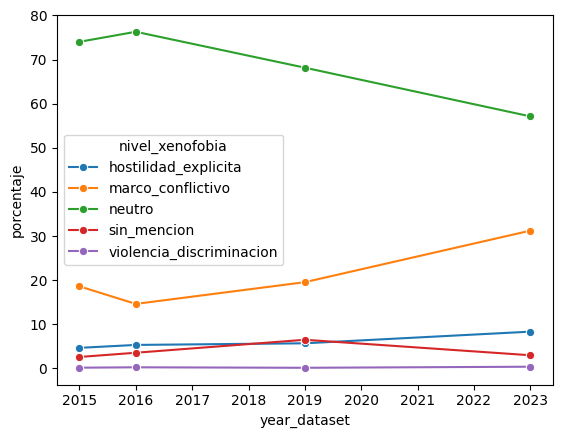

In [39]:
sns.lineplot(
    data=distribucion_xeno,
    x="year_dataset",
    y="porcentaje",
    hue="nivel_xenofobia",
    marker="o"
)

In [40]:
# Distribución de LGTBIfobia por año
distribucion_lgtbi = (
    df_lgtb
    .groupby(
        ["year_dataset", "nivel_lgtbifobia"]
    )
    .size()
    .reset_index(name="articulos")
)

distribucion_lgtbi["porcentaje"] = (
    distribucion_lgtbi["articulos"]
    / distribucion_lgtbi
        .groupby("year_dataset")["articulos"]
        .transform("sum")
    * 100
).round(2)

distribucion_lgtbi

,year_dataset,nivel_lgtbifobia,articulos,porcentaje
0,2015,hostilidad_explicita,79,4.16
1,2015,marco_conflictivo,46,2.42
2,2015,neutro,1430,75.26
3,2015,sin_mencion,219,11.53
4,2015,violencia_discriminacion,126,6.63
5,2016,hostilidad_explicita,146,4.87
6,2016,marco_conflictivo,83,2.77
7,2016,neutro,2186,72.96
8,2016,sin_mencion,265,8.85
9,2016,violencia_discriminacion,316,10.55


<Axes: xlabel='year_dataset', ylabel='porcentaje'>

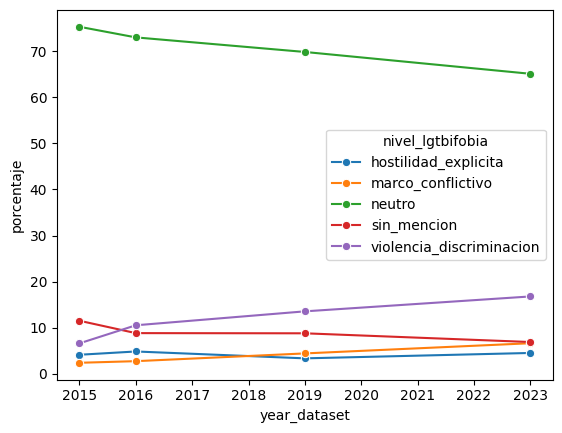

In [41]:
sns.lineplot(
    data=distribucion_lgtbi,
    x="year_dataset",
    y="porcentaje",
    hue="nivel_lgtbifobia",
    marker="o"
)

In [42]:
df_inmigracion[
    df_inmigracion["nivel_xenofobia"] == "hostilidad_explicita"
][["title"]].sample(30, random_state=42)

,title
54850,EE. UU detiene a cientos de migrantes en El Pa...
2542,La guerra en Siria cuadruplica la entrada de r...
23831,Abre sus instalaciones el centro temporal de a...
37740,"""Mi hermano me preguntó: '¿Me pego el brinco p..."
63120,"Musk visita la frontera de EEUU: ""Soy proinmig..."
56066,La Comisión Europea reconoce el liderazgo de E...
68943,Llegan otros 50 inmigrantes ilegales en un cay...
64168,El rechazo a la inmigración monopoliza la camp...
35021,"Ortega Smith quiere devolver la ""libertad"" a M..."
24350,Trump promete deportar o encarcelar hasta «tre...


In [43]:
df_lgtb[
    df_lgtb["nivel_lgtbifobia"] == "violencia_discriminacion"
][["title"]].sample(30, random_state=42)

,title
90040,"La LGTBIfobia, en datos: el 70% de la població..."
86232,Jakub Jankto y el largo partido contra el tabú...
91208,Ya funciona el 028: teléfono de atención al co...
78060,Dos de cada diez jóvenes canarios homosexuales...
86127,"Muere Brianna Ghey, conocida tiktoker transgén..."
81623,PP y Vox revisan las leyes LGTBI
87815,Alhaurín de la Torre se une con voz unánime pa...
91743,"Loles López apuesta por el ""compromiso"" y la ""..."
93345,"¿Qué hacen Google, Meta y TikTok para frenar e..."
73661,Concentraciones en contra del acoso escolar po...


In [44]:
RUTA_CLASIFICACION = (
    RUTA_TABLAS_PRENSA
    / "clasificacion"
)

RUTA_CLASIFICACION.mkdir(
    parents=True,
    exist_ok=True
)

distribucion_xeno.to_csv(
    RUTA_CLASIFICACION / "distribucion_xenofobia.csv",
    index=False,
    encoding="utf-8-sig"
)

distribucion_lgtbi.to_csv(
    RUTA_CLASIFICACION / "distribucion_lgtbifobia.csv",
    index=False,
    encoding="utf-8-sig"
)

In [45]:
xeno_resumen = (
    distribucion_xeno
    .pivot(
        index='year_dataset',
        columns='nivel_xenofobia',
        values='porcentaje'
    )
    .reset_index()
)

lgtb_resumen = (
    distribucion_lgtbi
    .pivot(
        index='year_dataset',
        columns='nivel_lgtbifobia',
        values='porcentaje'
    )
    .reset_index()
)

In [46]:
prensa_final = xeno_resumen.merge(
    lgtb_resumen,
    on='year_dataset',
    suffixes=('_xeno', '_lgtb')
)

In [47]:
prensa_final

,year_dataset,hostilidad_explicita_xeno,marco_conflictivo_xeno,neutro_xeno,sin_mencion_xeno,violencia_discriminacion_xeno,hostilidad_explicita_lgtb,marco_conflictivo_lgtb,neutro_lgtb,sin_mencion_lgtb,violencia_discriminacion_lgtb
0,2015,4.65,18.59,74.03,2.58,0.15,4.16,2.42,75.26,11.53,6.63
1,2016,5.31,14.61,76.30,3.54,0.24,4.87,2.77,72.96,8.85,10.55
2,2019,5.68,19.54,68.16,6.48,0.13,3.38,4.45,69.80,8.81,13.57
3,2023,8.32,31.22,57.12,2.97,0.37,4.55,6.66,65.07,6.92,16.80


In [48]:
import pandas as pd

datos_final = pd.read_csv(
    BASE
    / "01_data"
    / "03_final"
    / "datos_final.csv"
)

datos_final.head()

,año,mes,comunidad,Centro,Derecha,Extrema derecha,Izquierda,total_votos_clasificados,pct_Centro,pct_Derecha,...,DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD,DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO,DISFOBIA,IDEOLOGIA,ISLAMOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,RACISMO/XENOFOBIA,TOTAL ámbitos,pct_inmigrantes,delitos_por_100k
0,2015,12,Andalucía,1443272.0,1930919.0,10831.0,1017294.0,4402316.0,32.784380,43.861436,...,0,2,42,28,0,15,50,142,7.407718,1.692694
1,2015,12,Aragón,174281.0,361840.0,1849.0,186666.0,724636.0,24.050834,49.934036,...,0,0,11,6,0,4,9,32,11.009203,2.414001
2,2015,12,Asturias,149668.0,275887.0,1715.0,188676.0,615946.0,24.298883,44.790777,...,0,1,4,8,0,1,5,22,3.730197,2.096580
3,2015,12,Baleares,106659.0,214467.0,0.0,156956.0,478082.0,22.309771,44.859878,...,0,5,8,2,0,4,5,25,17.814009,2.250221
4,2015,12,Canarias,230301.0,483815.0,1546.0,264209.0,979871.0,23.503196,49.375377,...,0,1,20,3,0,6,5,35,12.088360,1.665620


In [49]:
datos_electorales_anuales = (
    datos_final
    .sort_values(["año", "mes"])
    .drop_duplicates(
        subset=["comunidad", "año"],
        keep="last"
    )
    .copy()
)

In [50]:
columnas_pct = [
    'pct_Centro',
    'pct_Derecha',
    'pct_Extrema derecha',
    'pct_Izquierda'
]

for columna in columnas_pct:
    datos_final[f'{columna}_ponderado'] = (
        datos_final[columna] *
        datos_final['total_votos_clasificados']
    )

elecciones_nacional = (
    datos_final
    .groupby('año')
    .agg({
        'total_votos_clasificados': 'sum',
        'pct_Centro_ponderado': 'sum',
        'pct_Derecha_ponderado': 'sum',
        'pct_Extrema derecha_ponderado': 'sum',
        'pct_Izquierda_ponderado': 'sum',
        'paro_medio': 'mean',
        'pct_inmigrantes': 'mean',
        'Gini': 'mean',
        'delitos_por_100k': 'mean'
    })
    .reset_index()
)

columnas_pct = [
    "pct_Centro",
    "pct_Derecha",
    "pct_Extrema derecha",
    "pct_Izquierda",
]

for columna in columnas_pct:
    datos_electorales_anuales[f"{columna}_ponderado"] = (
        datos_electorales_anuales[columna]
        * datos_electorales_anuales["total_votos_clasificados"]
    )

elecciones_nacional = (
    datos_electorales_anuales
    .groupby("año")
    .agg({
        "total_votos_clasificados": "sum",
        "pct_Centro_ponderado": "sum",
        "pct_Derecha_ponderado": "sum",
        "pct_Extrema derecha_ponderado": "sum",
        "pct_Izquierda_ponderado": "sum",
        "paro_medio": "mean",
        "pct_inmigrantes": "mean",
        "Gini": "mean",
        "delitos_por_100k": "mean",
    })
    .reset_index()
)

In [51]:
prensa_final = prensa_final.rename(
    columns={'year_dataset': 'año'}
)

df_integrado = elecciones_nacional.merge(
    prensa_final,
    on='año',
    how='inner'
)

df_integrado

,año,total_votos_clasificados,pct_Centro_ponderado,pct_Derecha_ponderado,pct_Extrema derecha_ponderado,pct_Izquierda_ponderado,paro_medio,pct_inmigrantes,Gini,delitos_por_100k,hostilidad_explicita_xeno,marco_conflictivo_xeno,neutro_xeno,sin_mencion_xeno,violencia_discriminacion_xeno,hostilidad_explicita_lgtb,marco_conflictivo_lgtb,neutro_lgtb,sin_mencion_lgtb,violencia_discriminacion_lgtb
0,2015,24906678.0,580923600.0,1.192352e+09,6560900.0,710831300.0,222721.421053,9.090452,32.294737,2.681552,4.65,18.59,74.03,2.58,0.15,4.16,2.42,75.26,11.53,6.63
1,2016,23776104.0,574718600.0,1.198300e+09,5709100.0,598882900.0,203626.210526,9.038631,32.152632,2.960649,5.31,14.61,76.30,3.54,0.24,4.87,2.77,72.96,8.85,10.55
2,2019,23902384.0,713259800.0,7.829952e+08,365759500.0,528223900.0,165723.947368,9.645426,31.394737,3.230495,5.68,19.54,68.16,6.48,0.13,3.38,4.45,69.80,8.81,13.57
3,2023,24306700.0,809012900.0,9.034122e+08,305700000.0,412544900.0,145602.315789,11.329677,30.768421,5.436568,8.32,31.22,57.12,2.97,0.37,4.55,6.66,65.07,6.92,16.80


In [52]:
elecciones_nacional.to_csv(
    BASE
    / "01_data"
    / "03_final"
    / "elecciones_nacional.csv",
    index=False,
    encoding="utf-8-sig"
)

df_integrado.to_csv(
    RUTA_TABLAS_INTEGRADO
    / "prensa_elecciones_integrado.csv",
    index=False,
    encoding="utf-8-sig"
)

In [53]:
df_integrado.head()

,año,total_votos_clasificados,pct_Centro_ponderado,pct_Derecha_ponderado,pct_Extrema derecha_ponderado,pct_Izquierda_ponderado,paro_medio,pct_inmigrantes,Gini,delitos_por_100k,hostilidad_explicita_xeno,marco_conflictivo_xeno,neutro_xeno,sin_mencion_xeno,violencia_discriminacion_xeno,hostilidad_explicita_lgtb,marco_conflictivo_lgtb,neutro_lgtb,sin_mencion_lgtb,violencia_discriminacion_lgtb
0,2015,24906678.0,580923600.0,1.192352e+09,6560900.0,710831300.0,222721.421053,9.090452,32.294737,2.681552,4.65,18.59,74.03,2.58,0.15,4.16,2.42,75.26,11.53,6.63
1,2016,23776104.0,574718600.0,1.198300e+09,5709100.0,598882900.0,203626.210526,9.038631,32.152632,2.960649,5.31,14.61,76.30,3.54,0.24,4.87,2.77,72.96,8.85,10.55
2,2019,23902384.0,713259800.0,7.829952e+08,365759500.0,528223900.0,165723.947368,9.645426,31.394737,3.230495,5.68,19.54,68.16,6.48,0.13,3.38,4.45,69.80,8.81,13.57
3,2023,24306700.0,809012900.0,9.034122e+08,305700000.0,412544900.0,145602.315789,11.329677,30.768421,5.436568,8.32,31.22,57.12,2.97,0.37,4.55,6.66,65.07,6.92,16.80


## Por meses

In [54]:
df_inmigracion['fecha'] = pd.to_datetime(df_inmigracion['publish_date'])

df_inmigracion['mes'] = (
    df_inmigracion['fecha']
    .dt.to_period('M')
)

In [55]:
evolucion = (
    df_inmigracion
    .groupby(['mes','nivel_xenofobia'])
    .size()
    .unstack(fill_value=0)
)

In [56]:

evolucion_pct = evolucion.div(
    evolucion.sum(axis=1),
    axis=0
) * 100

<Axes: xlabel='mes'>

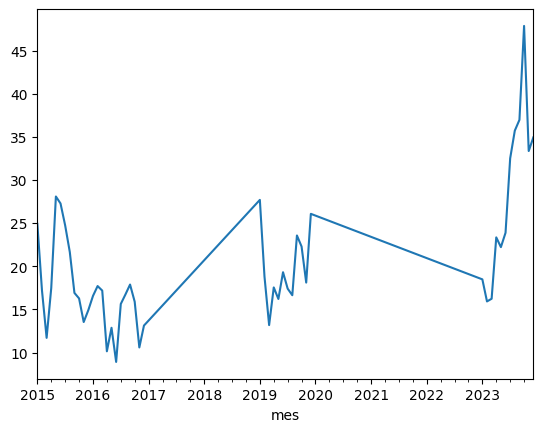

In [57]:
evolucion_pct['marco_conflictivo'].plot()

In [58]:
evolucion_pct.loc['2015']

nivel_xenofobia,hostilidad_explicita,marco_conflictivo,neutro,sin_mencion,violencia_discriminacion
mes,,,,,
2015-01,3.157895,24.912281,68.070175,3.859649,0.000000
2015-02,9.765625,17.187500,71.093750,1.953125,0.000000
2015-03,3.396226,11.698113,80.377358,3.018868,1.509434
2015-04,2.946955,17.485265,76.620825,2.750491,0.196464
2015-05,10.296412,28.081123,58.658346,2.964119,0.000000
2015-06,9.358289,27.272727,58.021390,5.080214,0.267380
2015-07,5.645161,24.731183,67.741935,1.881720,0.000000
2015-08,8.785942,21.645367,67.571885,1.837061,0.159744
2015-09,2.867502,16.908372,78.740936,1.351351,0.131839


In [59]:
evolucion_pct.loc['2016']

nivel_xenofobia,hostilidad_explicita,marco_conflictivo,neutro,sin_mencion,violencia_discriminacion
mes,,,,,
2016-01,6.028708,16.555024,73.779904,3.540670,0.095694
2016-02,6.200676,17.700113,73.618940,2.480271,0.000000
2016-03,5.661578,17.175573,74.872774,2.099237,0.190840
2016-04,7.142857,10.141093,79.453263,3.174603,0.088183
2016-05,4.470803,12.864964,79.470803,3.193431,0.000000
2016-06,4.604605,8.908909,82.282282,4.104104,0.100100
2016-07,3.255208,15.625000,77.734375,3.385417,0.000000
2016-08,6.504065,16.724739,71.777003,3.948897,1.045296
2016-09,3.539020,17.876588,73.411978,4.537205,0.635209


In [60]:
evolucion_pct.loc['2019']

nivel_xenofobia,hostilidad_explicita,marco_conflictivo,neutro,sin_mencion,violencia_discriminacion
mes,,,,,
2019-01,10.433387,27.688604,56.821830,4.975923,0.080257
2019-02,5.449591,18.801090,66.348774,9.400545,0.000000
2019-03,4.800817,13.176711,70.888662,10.010215,1.123596
2019-04,6.754221,17.542214,66.885553,8.724203,0.093809
2019-05,7.509881,16.205534,67.490119,8.794466,0.000000
2019-06,10.420032,19.305331,64.781906,5.411955,0.080775
2019-07,5.984252,17.401575,74.015748,2.519685,0.078740
2019-08,4.288165,16.638079,74.785592,4.219554,0.068611
2019-09,4.054054,23.564189,60.304054,12.077703,0.000000


# Bloque 8 · Sentimiento

In [61]:
from transformers import pipeline
from tqdm.auto import tqdm

tqdm.pandas()

c:\Users\herre\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
modelo_sentimiento = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 40637.00it/s]


In [63]:
def analizar_sentimiento(texto):
    try:
        resultado = modelo_sentimiento(
            str(texto)[:512]
        )[0]

        etiqueta = resultado["label"]

        if etiqueta == "positive":
            return "Positivo"

        elif etiqueta == "negative":
            return "Negativo"

        else:
            return "Neutral"

    except:
        return "Neutral"

In [64]:
print("Analizando inmigración...")

df_inmigracion["sentimiento"] = (
    df_inmigracion["texto"]
    .progress_apply(analizar_sentimiento)
)

print("Analizando LGTBI...")

df_lgtb["sentimiento"] = (
    df_lgtb["texto"]
    .progress_apply(analizar_sentimiento)
)

Analizando inmigración...


100%|██████████| 56988/56988 [1:07:53<00:00, 13.99it/s]


Analizando LGTBI...


100%|██████████| 18163/18163 [19:49<00:00, 15.27it/s]


In [65]:
print(df_inmigracion["sentimiento"].value_counts())

print()

print(df_lgtb["sentimiento"].value_counts())

sentimiento
Negativo    30412
Neutral     24887
Positivo     1689
Name: count, dtype: int64

sentimiento
Negativo    8723
Neutral     7867
Positivo    1573
Name: count, dtype: int64


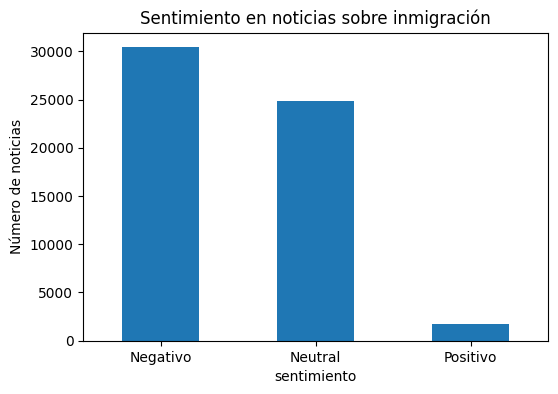

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

(
    df_inmigracion["sentimiento"]
    .value_counts()
    .plot(kind="bar", ax=ax)
)

plt.title("Sentimiento en noticias sobre inmigración")
plt.ylabel("Número de noticias")
plt.xticks(rotation=0)
plt.show()

# Bloque 9 · Trigramas

In [67]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# ============================
# TRIGRAMAS MÁS FRECUENTES
# ============================

vectorizador_trigramas = CountVectorizer(
    ngram_range=(3, 3),
    min_df=5
)

matriz_trigramas = vectorizador_trigramas.fit_transform(
    df_nlp["texto_limpio"].fillna("")
)

frecuencias_trigramas = matriz_trigramas.sum(axis=0).A1
nombres_trigramas = vectorizador_trigramas.get_feature_names_out()

trigramas = (
    pd.DataFrame({
        "trigrama": nombres_trigramas,
        "frecuencia": frecuencias_trigramas
    })
    .sort_values("frecuencia", ascending=False)
    .reset_index(drop=True)
)

display(trigramas.head(30))

,trigrama,frecuencia
0,la guardia civil,17264
1,en el que,15706
2,uno de los,15298
3,en la que,13919
4,la unión europea,12332
5,de las personas,10869
6,de la ue,10251
7,una de las,9890
8,por lo que,9343
9,de la guardia,9277


In [68]:
# ========================================
# FILTRAR TRIGRAMAS POCO INFORMATIVOS
# ========================================

trigramas_genericos = {
    "en el que",
    "uno de los",
    "en la que",
    "de las personas",
    "una de las",
    "por lo que",
    "después de que",
    "un total de",
    "en los últimos",
    "las personas que",
    "el número de",
    "se trata de",
    "la mayoría de",
    "por su parte",
    "que se ha",
    "en lo que",
    "por parte de"
}

trigramas_filtrados = (
    trigramas[
        ~trigramas["trigrama"].isin(trigramas_genericos)
    ]
    .reset_index(drop=True)
)

display(trigramas_filtrados.head(30))

,trigrama,frecuencia
0,la guardia civil,17264
1,la unión europea,12332
2,de la ue,10251
3,de la guardia,9277
4,la llegada de,9168
5,de los refugiados,8911
6,solicitantes de asilo,7669
7,de la unión,7249
8,de la policía,6892
9,en el mar,6638


In [69]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd


def obtener_trigramas(df, anio, top=20, min_df=3):
    """
    Obtiene los trigramas más frecuentes de un año concreto.
    """

    datos = (
        df.loc[
            df["year_dataset"] == anio,
            "texto_limpio"
        ]
        .dropna()
        .astype(str)
    )

    if datos.empty:
        print(f"No hay textos disponibles para el año {anio}")
        return pd.DataFrame(
            columns=["trigrama", "frecuencia"]
        )

    vectorizador = CountVectorizer(
        ngram_range=(3, 3),
        min_df=min_df
    )

    matriz = vectorizador.fit_transform(datos)

    frecuencias = matriz.sum(axis=0).A1

    resultado = pd.DataFrame({
        "trigrama": vectorizador.get_feature_names_out(),
        "frecuencia": frecuencias
    })

    return (
        resultado
        .sort_values("frecuencia", ascending=False)
        .head(top)
        .reset_index(drop=True)
    )

In [70]:
trigramas_2015 = obtener_trigramas(df_nlp, 2015)
trigramas_2016 = obtener_trigramas(df_nlp, 2016)
trigramas_2019 = obtener_trigramas(df_nlp, 2019)
trigramas_2023 = obtener_trigramas(df_nlp, 2023)

In [71]:
print("========== 2015 ==========")
display(trigramas_2015)

print("========== 2016 ==========")
display(trigramas_2016)

print("========== 2019 ==========")
display(trigramas_2019)

print("========== 2023 ==========")
display(trigramas_2023)

========== 2015 ==========


,trigrama,frecuencia
0,la unión europea,3102
1,de los refugiados,3038
2,de la ue,2907
3,uno de los,2632
4,en la que,2219
5,en el que,2180
6,la guardia civil,1905
7,de la unión,1904
8,la comisión europea,1769
9,después de que,1663


========== 2016 ==========


,trigrama,frecuencia
0,de los refugiados,4084
1,la unión europea,3556
2,en el que,3176
3,uno de los,3166
4,la guardia civil,3101
5,de la ue,2767
6,en la que,2717
7,solicitantes de asilo,2058
8,después de que,1747
9,de la unión,1724


========== 2019 ==========


,trigrama,frecuencia
0,en el que,4398
1,la guardia civil,4330
2,uno de los,3717
3,en la que,3481
4,de la guardia,2816
5,una de las,2803
6,de las personas,2761
7,después de que,2749
8,en el mar,2692
9,un total de,2408


========== 2023 ==========


,trigrama,frecuencia
0,la guardia civil,7928
1,en el que,5952
2,uno de los,5783
3,de las personas,5746
4,en la que,5502
5,la llegada de,4368
6,una de las,4112
7,por lo que,3889
8,la unión europea,3887
9,de la guardia,3745


In [72]:
total_palabras = (
    df_inmigracion
    .groupby("year_dataset")["texto_limpio"]
    .apply(
        lambda textos: textos
        .fillna("")
        .str.split()
        .str.len()
        .sum()
    )
)

total_palabras

year_dataset
2015     4575594
2016     5651420
2019     6760201
2023    10534249
Name: texto_limpio, dtype: int64

In [73]:
trigramas_2015["year_dataset"] = 2015
trigramas_2016["year_dataset"] = 2016
trigramas_2019["year_dataset"] = 2019
trigramas_2023["year_dataset"] = 2023

trigramas_comparados = pd.concat(
    [
        trigramas_2015,
        trigramas_2016,
        trigramas_2019,
        trigramas_2023
    ],
    ignore_index=True
)

trigramas_comparados.head()

,trigrama,frecuencia,year_dataset
0,la unión europea,3102,2015
1,de los refugiados,3038,2015
2,de la ue,2907,2015
3,uno de los,2632,2015
4,en la que,2219,2015


In [74]:
trigramas_2015["year_dataset"] = 2015
trigramas_2016["year_dataset"] = 2016
trigramas_2019["year_dataset"] = 2019
trigramas_2023["year_dataset"] = 2023

trigramas_comparados = pd.concat(
    [
        trigramas_2015,
        trigramas_2016,
        trigramas_2019,
        trigramas_2023
    ],
    ignore_index=True
)

trigramas_comparados.head()

,trigrama,frecuencia,year_dataset
0,la unión europea,3102,2015
1,de los refugiados,3038,2015
2,de la ue,2907,2015
3,uno de los,2632,2015
4,en la que,2219,2015


In [75]:
trigramas_comparados["total_palabras"] = (
    trigramas_comparados["year_dataset"]
    .map(total_palabras)
)

trigramas_comparados["frecuencia_millon"] = (
    trigramas_comparados["frecuencia"]
    / trigramas_comparados["total_palabras"]
    * 1_000_000
).round(2)

display(trigramas_comparados)

,trigrama,frecuencia,year_dataset,total_palabras,frecuencia_millon
0,la unión europea,3102,2015,4575594,677.94
1,de los refugiados,3038,2015,4575594,663.96
2,de la ue,2907,2015,4575594,635.33
3,uno de los,2632,2015,4575594,575.23
4,en la que,2219,2015,4575594,484.96
...,...,...,...,...,...
75,en lo que,3107,2023,10534249,294.94
76,el gobierno de,3087,2023,10534249,293.04
77,solicitantes de asilo,3085,2023,10534249,292.85
78,la policía nacional,2967,2023,10534249,281.65


In [76]:
trigramas_comparados.groupby("year_dataset").size()

year_dataset
2015    20
2016    20
2019    20
2023    20
dtype: int64

In [77]:
trigramas_genericos = {
    "en el que",
    "uno de los",
    "en la que",
    "una de las",
    "por lo que",
    "después de que",
    "un total de",
    "en los últimos",
    "las personas que",
    "el número de",
    "se trata de",
    "la mayoría de",
    "por su parte",
    "que se ha",
    "en lo que",
    "por parte de"
}

trigramas_tematicos = (
    trigramas_comparados[
        ~trigramas_comparados["trigrama"]
        .isin(trigramas_genericos)
    ]
    .copy()
    .reset_index(drop=True)
)

display(trigramas_tematicos)

,trigrama,frecuencia,year_dataset,total_palabras,frecuencia_millon
0,la unión europea,3102,2015,4575594,677.94
1,de los refugiados,3038,2015,4575594,663.96
2,de la ue,2907,2015,4575594,635.33
3,la guardia civil,1905,2015,4575594,416.34
4,de la unión,1904,2015,4575594,416.12
5,la comisión europea,1769,2015,4575594,386.62
6,los países de,1599,2015,4575594,349.46
7,de la guardia,1495,2015,4575594,326.73
8,la crisis de,1486,2015,4575594,324.77
9,la llegada de,1427,2015,4575594,311.87


In [78]:
trigramas_tematicos.groupby("year_dataset").size()

year_dataset
2015    14
2016    11
2019    10
2023    10
dtype: int64

In [79]:
top_tematicos = (
    trigramas_tematicos
    .sort_values(
        ["year_dataset", "frecuencia_millon"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_tematicos)

,trigrama,frecuencia,year_dataset,total_palabras,frecuencia_millon
0,la unión europea,3102,2015,4575594,677.94
1,de los refugiados,3038,2015,4575594,663.96
2,de la ue,2907,2015,4575594,635.33
3,la guardia civil,1905,2015,4575594,416.34
4,de la unión,1904,2015,4575594,416.12
5,la comisión europea,1769,2015,4575594,386.62
6,los países de,1599,2015,4575594,349.46
7,de la guardia,1495,2015,4575594,326.73
8,la crisis de,1486,2015,4575594,324.77
9,la llegada de,1427,2015,4575594,311.87


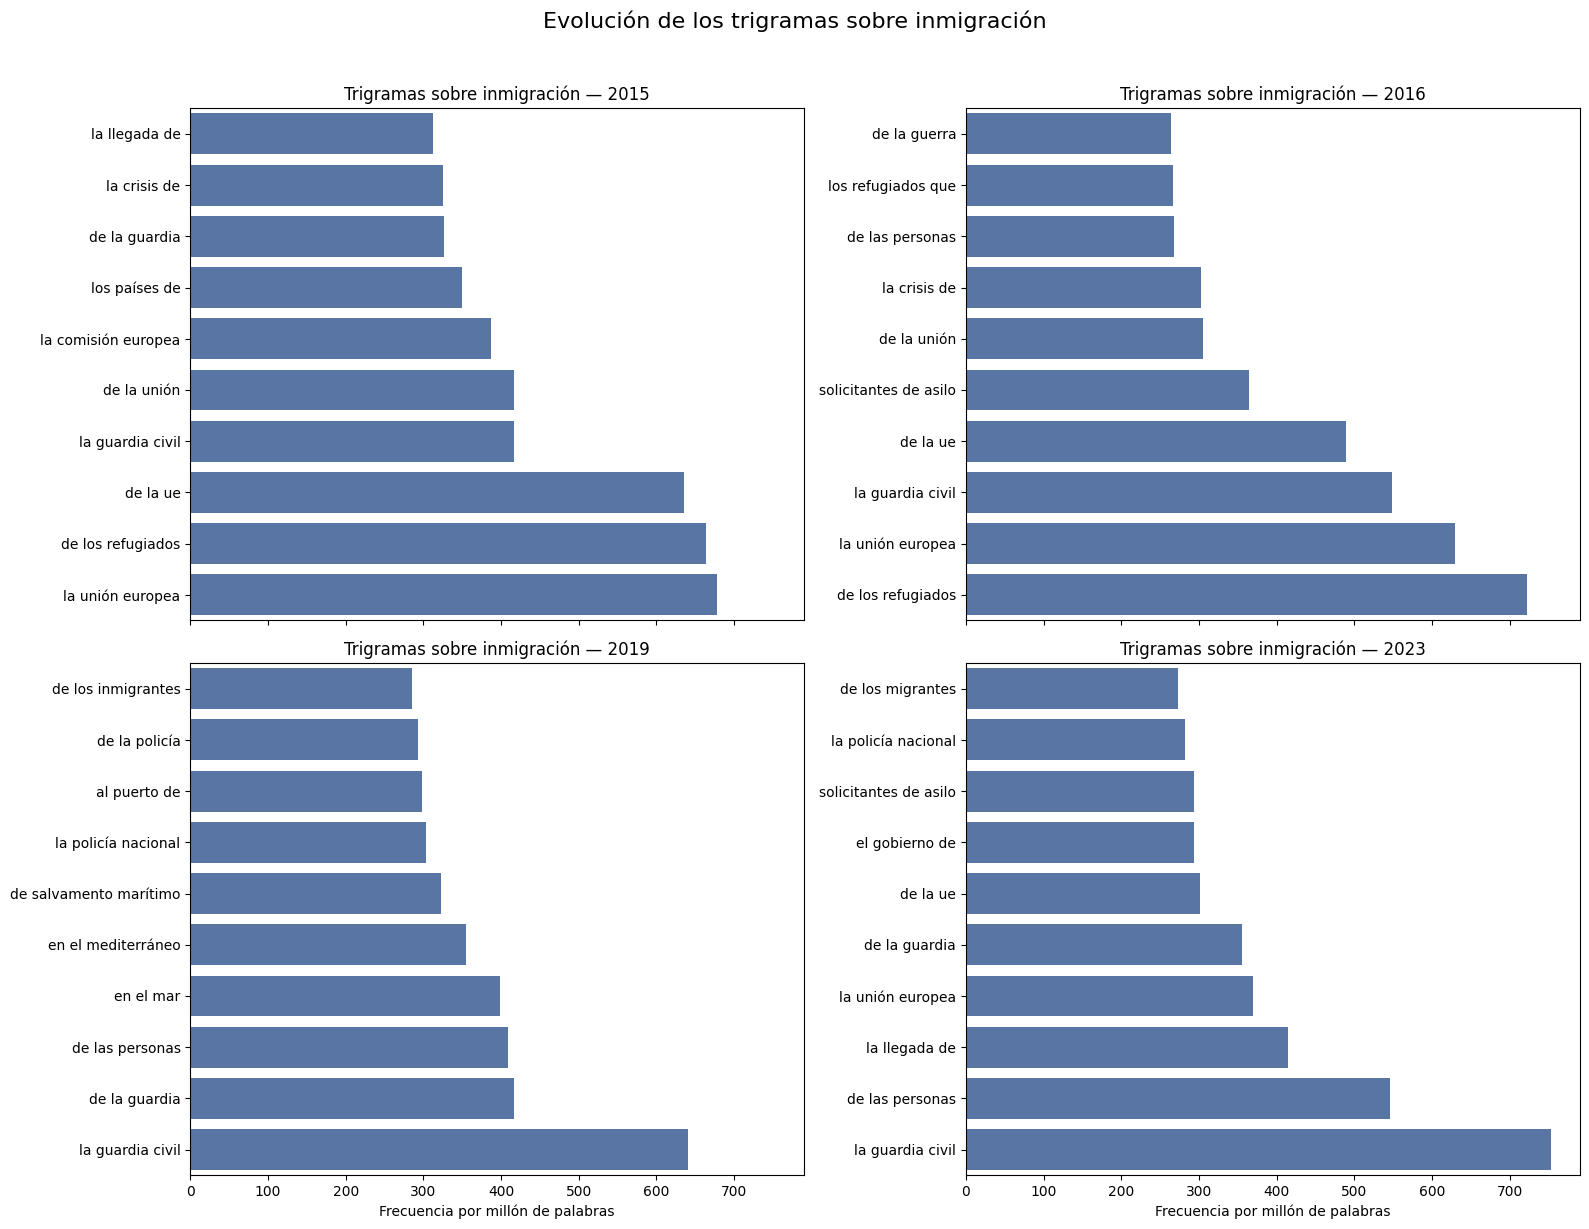

In [80]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12),
    sharex=True
)

axes = axes.flatten()
años = [2015, 2016, 2019, 2023]

for ax, año in zip(axes, años):

    datos_año = (
        top_tematicos[
            top_tematicos["year_dataset"] == año
        ]
        .sort_values("frecuencia_millon")
    )

    sns.barplot(
        data=datos_año,
        x="frecuencia_millon",
        y="trigrama",
        ax=ax,
        color="#4C72B0"
    )

    ax.set_title(f"Trigramas sobre inmigración — {año}")
    ax.set_xlabel("Frecuencia por millón de palabras")
    ax.set_ylabel("")
    fig.suptitle(
    "Evolución de los trigramas sobre inmigración",
    fontsize=16,
    y=1.02
    )

plt.tight_layout()
plt.show()

In [84]:
plt.tight_layout()

plt.savefig(
    RUTA_FIGURAS_TRIGRAMAS
    / "trigramas_inmigracion_por_anio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [85]:
RUTA_TRIGRAMAS = (
    RUTA_FIGURAS_PRENSA
    / "trigramas"
)

RUTA_TRIGRAMAS.mkdir(
    parents=True,
    exist_ok=True
)

In [86]:
RUTA_TRIGRAMAS / "trigramas_inmigracion_por_anio.png"
RUTA_TRIGRAMAS / "wordcloud_trigramas_inmigracion.png"
RUTA_TRIGRAMAS / "wordcloud_trigramas_lgtbi.png"

WindowsPath('C:/Users/herre/OneDrive/Desktop/Proyectos DATA/SPRINT 13/03_outputs/figures/prensa/trigramas/wordcloud_trigramas_lgtbi.png')

# Bloque 10 · WorldCloud

In [87]:
!pip install wordcloud

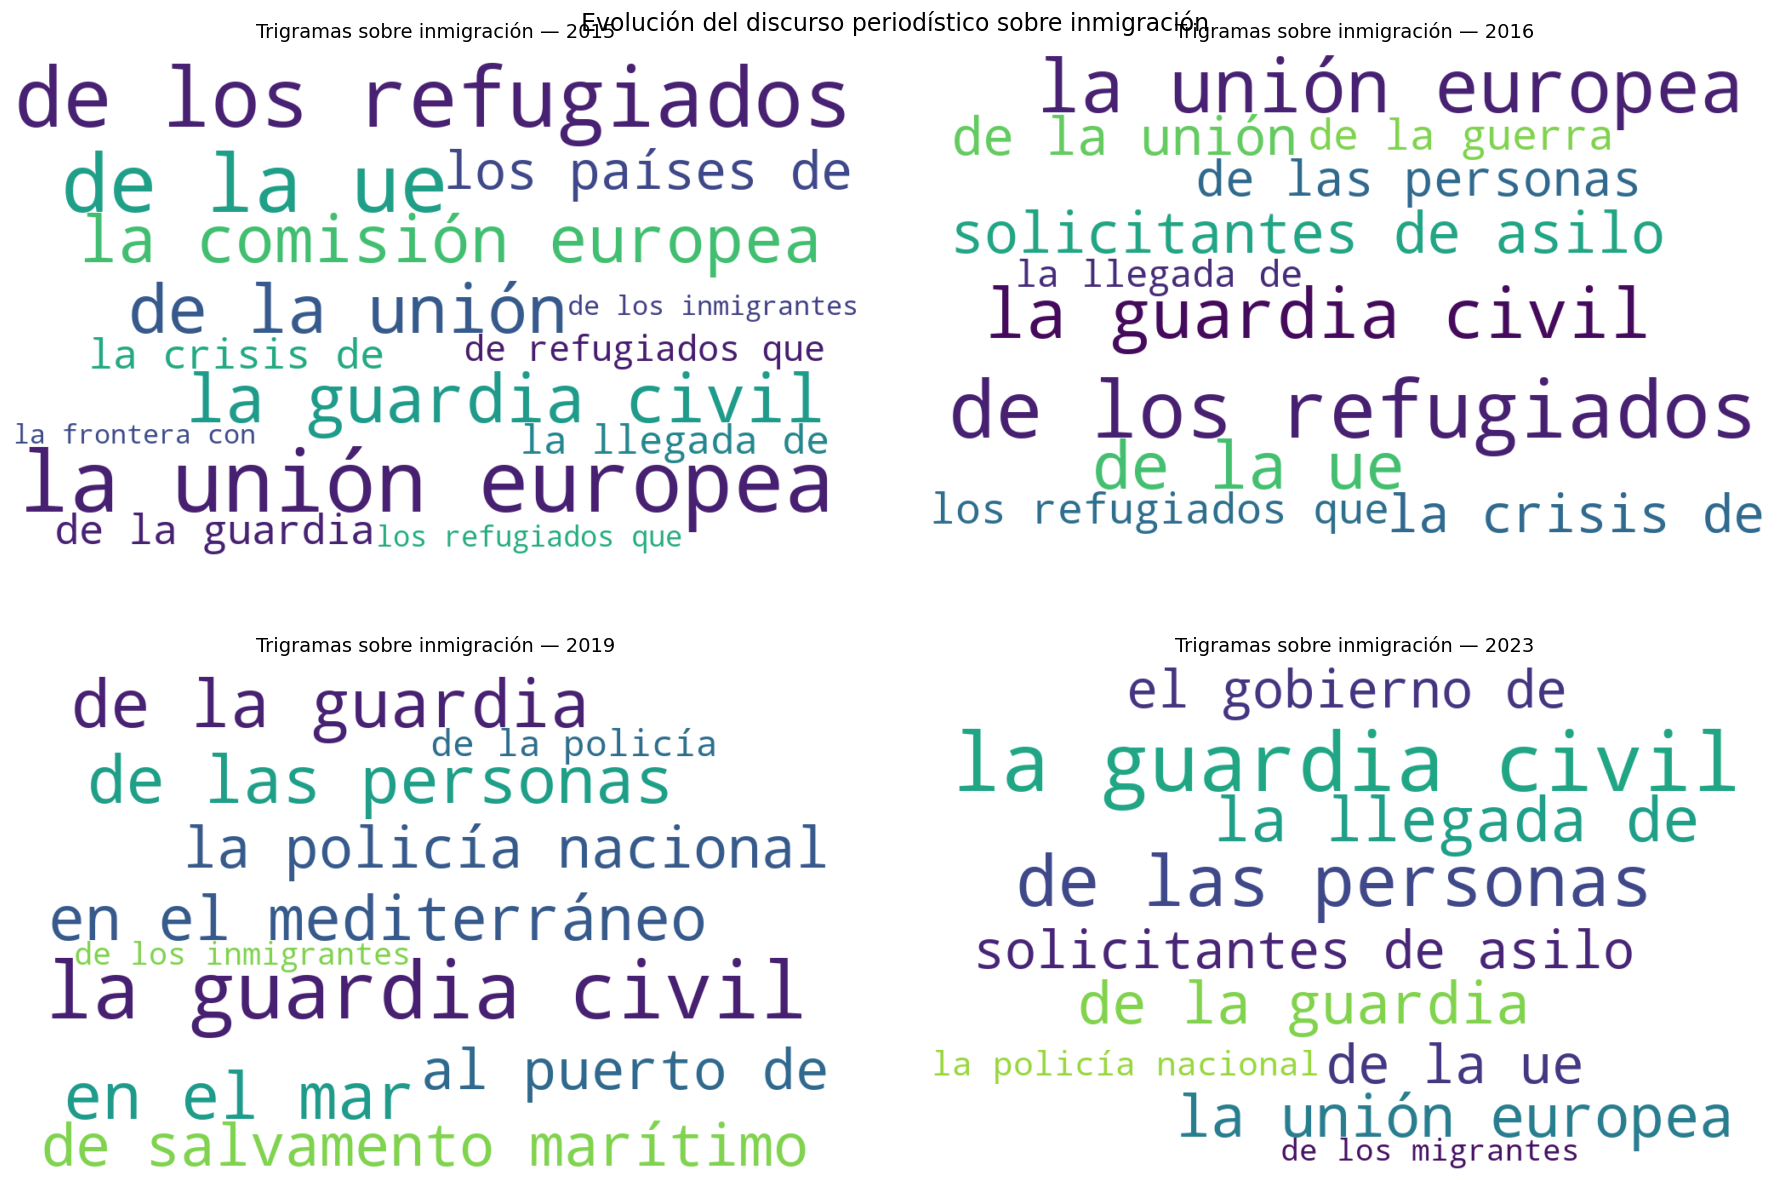

In [89]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

axes = axes.flatten()
años = [2015, 2016, 2019, 2023]

for ax, año in zip(axes, años):

    datos_año = trigramas_tematicos[
        trigramas_tematicos["year_dataset"] == año
    ]

    frecuencias = dict(
        zip(
            datos_año["trigrama"],
            datos_año["frecuencia_millon"]
        )
    )

    nube = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        colormap="viridis",
        prefer_horizontal=1,
        max_words=20,
        random_state=42
    ).generate_from_frequencies(frecuencias)

    ax.imshow(
        nube,
        interpolation="bilinear"
    )

    ax.set_title(
        f"Trigramas sobre inmigración — {año}",
        fontsize=14
    )

    ax.axis("off")

fig.suptitle(
    "Evolución del discurso periodístico sobre inmigración",
    fontsize=17
)

plt.tight_layout()

plt.subplots_adjust(
    hspace=0.20,
    wspace=0.08
)

plt.savefig(
    RUTA_FIGURAS_TRIGRAMAS
    / "wordcloud_trigramas_inmigracion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
trigramas_lgtb_2015 = obtener_trigramas(df_lgtb, 2015)
trigramas_lgtb_2016 = obtener_trigramas(df_lgtb, 2016)
trigramas_lgtb_2019 = obtener_trigramas(df_lgtb, 2019)
trigramas_lgtb_2023 = obtener_trigramas(df_lgtb, 2023)

In [91]:
trigramas_lgtb_2015["year_dataset"] = 2015
trigramas_lgtb_2016["year_dataset"] = 2016
trigramas_lgtb_2019["year_dataset"] = 2019
trigramas_lgtb_2023["year_dataset"] = 2023

trigramas_lgtb_comparados = pd.concat(
    [
        trigramas_lgtb_2015,
        trigramas_lgtb_2016,
        trigramas_lgtb_2019,
        trigramas_lgtb_2023
    ],
    ignore_index=True
)

In [92]:
trigramas_lgtb_2015["year_dataset"] = 2015
trigramas_lgtb_2016["year_dataset"] = 2016
trigramas_lgtb_2019["year_dataset"] = 2019
trigramas_lgtb_2023["year_dataset"] = 2023

trigramas_lgtb_comparados = pd.concat(
    [
        trigramas_lgtb_2015,
        trigramas_lgtb_2016,
        trigramas_lgtb_2019,
        trigramas_lgtb_2023
    ],
    ignore_index=True
)

In [93]:
total_palabras_lgtb = (
    df_lgtb
    .groupby("year_dataset")["texto_limpio"]
    .apply(
        lambda textos: textos
        .fillna("")
        .str.split()
        .str.len()
        .sum()
    )
)

display(total_palabras_lgtb)

year_dataset
2015     929414
2016    1506300
2019    2734395
2023    4329026
Name: texto_limpio, dtype: int64

In [94]:
trigramas_lgtb_comparados["total_palabras"] = (
    trigramas_lgtb_comparados["year_dataset"]
    .map(total_palabras_lgtb)
)

trigramas_lgtb_comparados["frecuencia_millon"] = (
    trigramas_lgtb_comparados["frecuencia"]
    / trigramas_lgtb_comparados["total_palabras"]
    * 1_000_000
).round(2)

In [95]:
trigramas_lgtb_tematicos = (
    trigramas_lgtb_comparados[
        ~trigramas_lgtb_comparados["trigrama"]
        .isin(trigramas_genericos)
    ]
    .copy()
    .reset_index(drop=True)
)

top_lgtb_tematicos = (
    trigramas_lgtb_tematicos
    .sort_values(
        ["year_dataset", "frecuencia_millon"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_lgtb_tematicos)

,trigrama,frecuencia,year_dataset,total_palabras,frecuencia_millon
0,del mismo sexo,726,2015,929414,781.14
1,personas del mismo,400,2015,929414,430.38
2,de la iglesia,397,2015,929414,427.15
3,los derechos de,324,2015,929414,348.61
4,del orgullo gay,279,2015,929414,300.19
5,entre personas del,275,2015,929414,295.89
6,el matrimonio homosexual,261,2015,929414,280.82
7,de los derechos,257,2015,929414,276.52
8,de la comunidad,251,2015,929414,270.06
9,parejas del mismo,242,2015,929414,260.38


In [96]:
años = [2015, 2016, 2019, 2023]

tablas_lgtb = []

for año in años:

    tabla = obtener_trigramas(
        df_lgtb,
        año,
        top=100
    )

    tabla["year_dataset"] = año
    tablas_lgtb.append(tabla)

trigramas_lgtb_comparados = pd.concat(
    tablas_lgtb,
    ignore_index=True
)

In [97]:
trigramas_lgtb_comparados["total_palabras"] = (
    trigramas_lgtb_comparados["year_dataset"]
    .map(total_palabras_lgtb)
)

trigramas_lgtb_comparados["frecuencia_millon"] = (
    trigramas_lgtb_comparados["frecuencia"]
    / trigramas_lgtb_comparados["total_palabras"]
    * 1_000_000
).round(2)

In [98]:
trigramas_genericos_lgtb = trigramas_genericos.union({
    "de las personas",
    "que no se",
    "fuente el periódico",
    "los derechos de",
    "de los derechos",
    "de la comunidad",
    "la comunidad de",
    "la ley de",
    "de la ley"
})

In [99]:
trigramas_lgtb_tematicos = (
    trigramas_lgtb_comparados[
        ~trigramas_lgtb_comparados["trigrama"]
        .isin(trigramas_genericos_lgtb)
    ]
    .copy()
)

top_lgtb_tematicos = (
    trigramas_lgtb_tematicos
    .sort_values(
        ["year_dataset", "frecuencia_millon"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_lgtb_tematicos)

,trigrama,frecuencia,year_dataset,total_palabras,frecuencia_millon
0,del mismo sexo,726,2015,929414,781.14
1,personas del mismo,400,2015,929414,430.38
2,de la iglesia,397,2015,929414,427.15
3,del orgullo gay,279,2015,929414,300.19
4,entre personas del,275,2015,929414,295.89
5,el matrimonio homosexual,261,2015,929414,280.82
6,parejas del mismo,242,2015,929414,260.38
7,el presidente de,207,2015,929414,222.72
8,su orientación sexual,204,2015,929414,219.49
9,el caso de,201,2015,929414,216.27


In [100]:
trigramas_genericos_lgtb.update({
    "el presidente de",
    "el caso de",
    "todo el mundo",
    "de la ciudad",
    "el que se",
    "el ayuntamiento de"
})

trigramas_lgtb_tematicos = (
    trigramas_lgtb_comparados[
        ~trigramas_lgtb_comparados["trigrama"]
        .isin(trigramas_genericos_lgtb)
    ]
    .copy()
)

top_lgtb_tematicos = (
    trigramas_lgtb_tematicos
    .sort_values(
        ["year_dataset", "frecuencia_millon"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

In [101]:
trigramas_genericos_lgtb.update({
    "el presidente de",
    "el caso de",
    "todo el mundo",
    "de la ciudad",
    "el que se",
    "el ayuntamiento de",
    "última hora del",
    "de que el",
    "la que se",
    "derechos de las",
    "de la policía",
    "en un comunicado",
    "de la familia",
    "de los homosexuales"
})

trigramas_lgtb_tematicos = (
    trigramas_lgtb_comparados[
        ~trigramas_lgtb_comparados["trigrama"]
        .isin(trigramas_genericos_lgtb)
    ]
    .copy()
)

top_lgtb_tematicos = (
    trigramas_lgtb_tematicos
    .sort_values(
        ["year_dataset", "frecuencia_millon"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

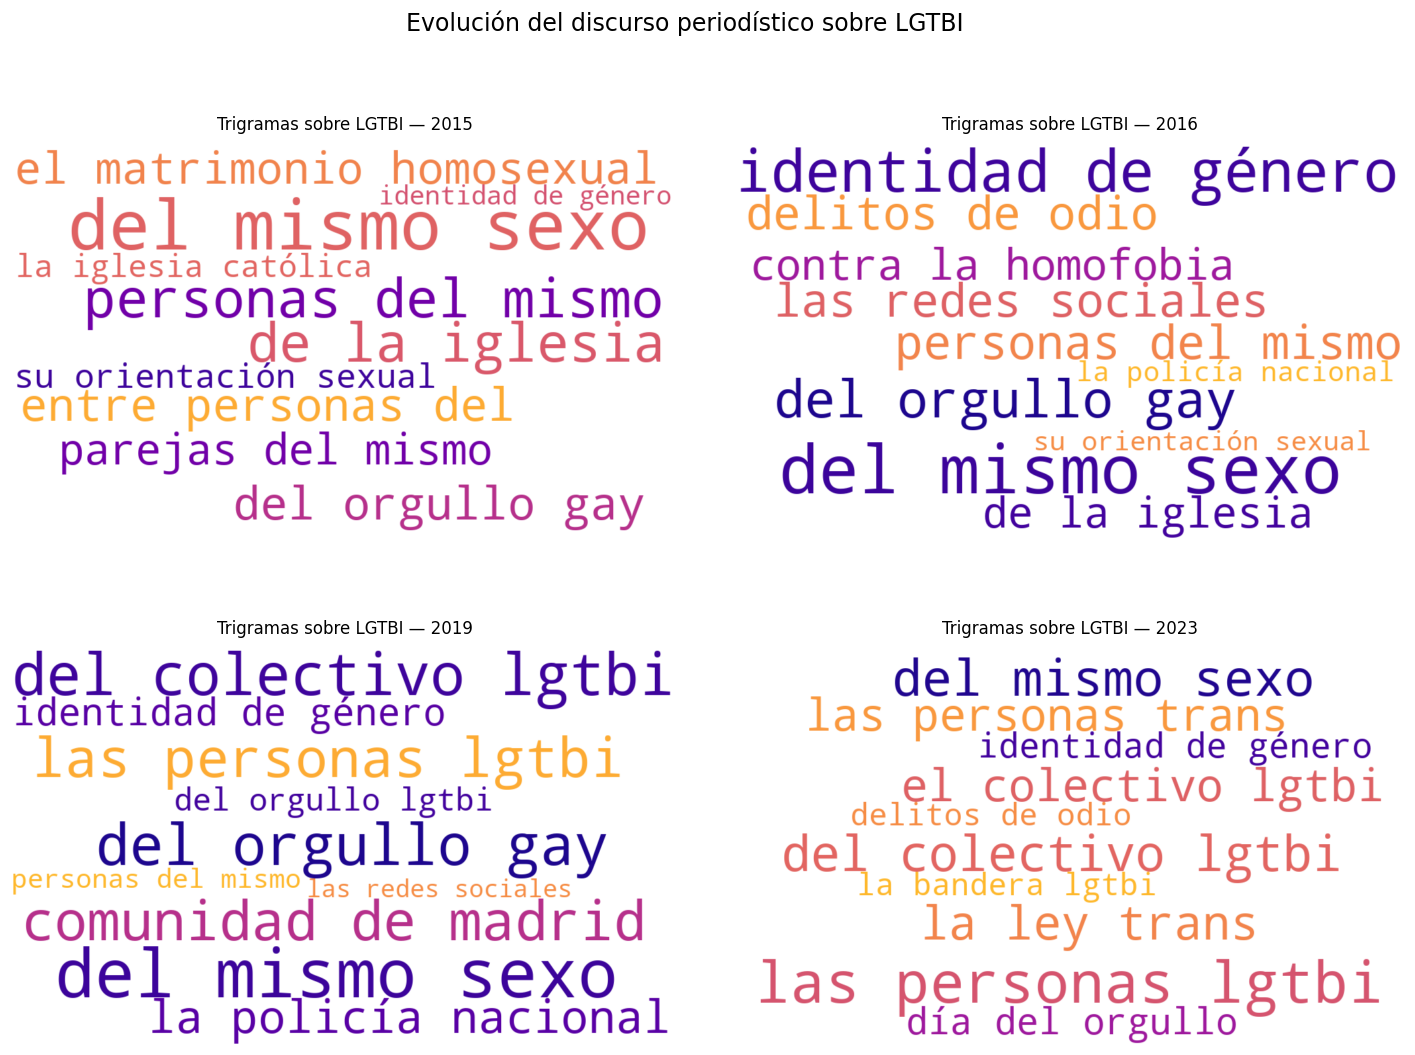

In [103]:
from wordcloud import WordCloud

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

axes = axes.flatten()

for ax, año in zip(axes, años):

    datos_año = top_lgtb_tematicos[
        top_lgtb_tematicos["year_dataset"] == año
    ]

    frecuencias = dict(
        zip(
            datos_año["trigrama"],
            datos_año["frecuencia_millon"]
        )
    )

    nube = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        colormap="plasma",
        prefer_horizontal=1,
        max_words=10,
        random_state=42
    ).generate_from_frequencies(frecuencias)

    ax.imshow(nube, interpolation="bilinear")
    ax.set_title(f"Trigramas sobre LGTBI — {año}")
    ax.axis("off")

fig.suptitle(
    "Evolución del discurso periodístico sobre LGTBI",
    fontsize=17
)

plt.subplots_adjust(
    hspace=0.20,
    wspace=0.08
)

plt.savefig(
    RUTA_FIGURAS_TRIGRAMAS
    / "wordcloud_trigramas_lgtbi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Bloque 11 · BerTopic

In [104]:
!pip install -U bertopic sentence-transformers umap-learn hdbscan

   ---------------------------------------- 0.0/596.7 kB ? eta -:--:--
   ----------------------------------- ---- 524.3/596.7 kB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 596.7/596.7 kB 3.7 MB/s  0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.6.0
    Uninstalling sentence-transformers-5.6.0:
      Successfully uninstalled sentence-transformers-5.6.0


In [105]:
df_bertopic_inmigracion = (
    df_inmigracion[
        [
            "title",
            "texto_limpio",
            "year_dataset"
        ]
    ]
    .dropna(subset=["texto_limpio"])
    .copy()
)

df_bertopic_inmigracion["documento"] = (
    df_bertopic_inmigracion["title"]
    .fillna("")
    .astype(str)
    + ". "
    + df_bertopic_inmigracion["texto_limpio"]
    .fillna("")
    .astype(str)
)

df_bertopic_inmigracion = (
    df_bertopic_inmigracion[
        df_bertopic_inmigracion["documento"].str.len() >= 50
    ]
    .reset_index(drop=True)
)

documentos_inmigracion = (
    df_bertopic_inmigracion["documento"]
    .tolist()
)

años_inmigracion = (
    df_bertopic_inmigracion["year_dataset"]
    .astype(int)
    .tolist()
)

print("Documentos:", len(documentos_inmigracion))
df_bertopic_inmigracion["year_dataset"].value_counts().sort_index()

Documentos: 56988


year_dataset
2015     9701
2016    11429
2019    15285
2023    20573
Name: count, dtype: int64

In [106]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

In [107]:
modelo_embeddings = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

vectorizador_bertopic = CountVectorizer(
    stop_words=list(stopwords_total),
    ngram_range=(1, 2),
    min_df=5
)

modelo_umap = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan = HDBSCAN(
    min_cluster_size=30,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

modelo_bertopic_inmigracion = BERTopic(
    embedding_model=modelo_embeddings,
    vectorizer_model=vectorizador_bertopic,
    umap_model=modelo_umap,
    hdbscan_model=modelo_hdbscan,
    language="multilingual",
    calculate_probabilities=False,
    verbose=True
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5923.91it/s]


In [108]:
temas_inmigracion, probabilidades_inmigracion = (
    modelo_bertopic_inmigracion.fit_transform(
        documentos_inmigracion
    )
)

2026-07-24 20:40:54,838 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1781/1781 [12:55<00:00,  2.30it/s]
2026-07-24 20:53:50,242 - BERTopic - Embedding - Completed ✓
2026-07-24 20:53:50,243 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 20:54:35,404 - BERTopic - Dimensionality - Completed ✓
2026-07-24 20:54:35,411 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 20:54:38,292 - BERTopic - Cluster - Completed ✓
2026-07-24 20:54:38,299 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 20:54:56,753 - BERTopic - Representation - Completed ✓


In [109]:
info_temas_inmigracion = (
    modelo_bertopic_inmigracion
    .get_topic_info()
)

display(info_temas_inmigracion.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,23528,-1_personas_migrantes_inmigrantes_refugiados,"[personas, migrantes, inmigrantes, refugiados,...",[Malestar en las comunidades por el reparto de...
1,0,928,0_vox_pp_inmigración_partido,"[vox, pp, inmigración, partido, gobierno, junt...",[Vox pide derogar Ley contra violencia machist...
2,1,696,1_detenido_policía nacional_policía_agentes,"[detenido, policía nacional, policía, agentes,...",[Siete detenidos en la provincia de Albacete p...
3,2,580,2_acogida_refugiados_ayuntamiento_acogida refu...,"[acogida, refugiados, ayuntamiento, acogida re...",[Grandes ciudades presionan a Rajoy con su pla...
4,3,518,3_prisión_acusado_audiencia_cárcel,"[prisión, acusado, audiencia, cárcel, acusados...",[Condenado a cuatro años de prisión por patron...
5,4,518,4_papa_francisco_papa francisco_pontífice,"[papa, francisco, papa francisco, pontífice, v...",[El Papa pide regular la inmigración con respo...
6,5,504,5_alemania_alemán_berlín_merkel,"[alemania, alemán, berlín, merkel, refugiados,...",[Alemania debate imponer un tope al asilo ante...
7,6,494,6_méxico_unidos_guatemala_frontera,"[méxico, unidos, guatemala, frontera, mexicano...",[México triplica las deportaciones de migrante...
8,7,469,7_marruecos_marroquí_rabat_marroquíes,"[marruecos, marroquí, rabat, marroquíes, dieta...",[Interior entregó a Marruecos 32 millones en «...
9,8,459,8_guardia costera_costera_marina_italiana,"[guardia costera, costera, marina, italiana, o...",[4.400 inmigrantes son rescatados en el Canal ...


In [110]:
embeddings_inmigracion = modelo_embeddings.encode(
    documentos_inmigracion,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 1781/1781 [18:12<00:00,  1.63it/s]


In [112]:
modelo_hdbscan_v2 = HDBSCAN(
    min_cluster_size=30,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

modelo_bertopic_inmigracion_v2 = BERTopic(
    embedding_model=modelo_embeddings,
    vectorizer_model=vectorizador_bertopic,
    umap_model=modelo_umap,
    hdbscan_model=modelo_hdbscan_v2,
    language="multilingual",
    calculate_probabilities=False,
    low_memory=True,
    verbose=True
)

In [113]:
temas_inmigracion_v2, probabilidades_inmigracion_v2 = (
    modelo_bertopic_inmigracion_v2.fit_transform(
        documentos_inmigracion,
        embeddings_inmigracion
    )
)

2026-07-24 22:20:29,628 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 22:21:15,530 - BERTopic - Dimensionality - Completed ✓
2026-07-24 22:21:15,532 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 22:21:19,047 - BERTopic - Cluster - Completed ✓
2026-07-24 22:21:19,062 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 22:21:53,227 - BERTopic - Representation - Completed ✓


In [114]:
def resumen_modelo(nombre, temas, modelo):

    temas_array = np.array(temas)
    total = len(temas_array)
    outliers = np.sum(temas_array == -1)
    temas_validos = len(set(temas_array)) - (
        1 if -1 in temas_array else 0
    )

    return {
        "modelo": nombre,
        "documentos": total,
        "outliers": outliers,
        "porcentaje_outliers": round(outliers / total * 100, 2),
        "temas_validos": temas_validos
    }

comparacion_modelos = pd.DataFrame([
    resumen_modelo(
        "Modelo inicial",
        temas_inmigracion,
        modelo_bertopic_inmigracion
    ),
    resumen_modelo(
        "Modelo min_samples=5",
        temas_inmigracion_v2,
        modelo_bertopic_inmigracion_v2
    )
])

display(comparacion_modelos)

,modelo,documentos,outliers,porcentaje_outliers,temas_validos
0,Modelo inicial,56988,23528,41.29,348
1,Modelo min_samples=5,56988,20608,36.16,459


In [115]:
info_temas_inmigracion_v2 = (
    modelo_bertopic_inmigracion_v2
    .get_topic_info()
)

display(info_temas_inmigracion_v2.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,20608,-1_personas_migrantes_inmigrantes_españa,"[personas, migrantes, inmigrantes, españa, ref...",[España destina 123 millones desde 2019 a fren...
1,0,742,0_ue_países_refugiados_reparto,"[ue, países, refugiados, reparto, europea, 000...",[La UE intenta este martes aprobar el reparto ...
2,1,673,1_detenido_policía nacional_policía_agentes,"[detenido, policía nacional, policía, agentes,...",[Detenidos cuatro empresarios por falsificar c...
3,2,592,2_prisión_acusado_audiencia_cárcel,"[prisión, acusado, audiencia, cárcel, delito, ...",[Condenado a cuatro años de prisión por patron...
4,3,520,3_papa_francisco_papa francisco_pontífice,"[papa, francisco, papa francisco, pontífice, v...",[El Papa pide regular la inmigración con respo...
5,4,465,4_griega_egeo_naufragio_guardia costera,"[griega, egeo, naufragio, guardia costera, cos...",[Al menos 59 migrantes mueren en el naufragio ...
6,5,460,5_grecia_idomeni_griego_atenas,"[grecia, idomeni, griego, atenas, lesbos, turq...",[Grecia creará 15 nuevos centros para acoger a...
7,6,449,6_acogida_acogida refugiados_acoger_acoger ref...,"[acogida, acogida refugiados, acoger, acoger r...",[Más de 55 Ayuntamientos ofrecen acoger y aten...
8,7,432,7_melilla_valla_salto_valla melilla,"[melilla, valla, salto, valla melilla, subsaha...",[Al menos 50 migrantes logran entrar en Melill...
9,8,430,8_turquía_ankara_ue_turco,"[turquía, ankara, ue, turco, davutoglu, 000 mi...",[Crisis de refugiados: La UE estudia devolver ...


In [116]:
modelo_umap_v3 = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan_v3 = HDBSCAN(
    min_cluster_size=100,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

In [117]:
modelo_bertopic_inmigracion_v3 = BERTopic(
    embedding_model=modelo_embeddings,
    vectorizer_model=vectorizador_bertopic,
    umap_model=modelo_umap_v3,
    hdbscan_model=modelo_hdbscan_v3,
    language="multilingual",
    calculate_probabilities=False,
    low_memory=True,
    verbose=True
)

temas_inmigracion_v3, probabilidades_inmigracion_v3 = (
    modelo_bertopic_inmigracion_v3.fit_transform(
        documentos_inmigracion,
        embeddings_inmigracion
    )
)

2026-07-24 22:22:07,982 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 22:22:49,646 - BERTopic - Dimensionality - Completed ✓
2026-07-24 22:22:49,648 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 22:22:50,832 - BERTopic - Cluster - Completed ✓
2026-07-24 22:22:50,838 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 22:23:09,880 - BERTopic - Representation - Completed ✓


In [118]:
comparacion_modelos = pd.DataFrame([
    resumen_modelo(
        "Inicial: cluster=30, samples=30",
        temas_inmigracion,
        modelo_bertopic_inmigracion
    ),
    resumen_modelo(
        "V2: cluster=30, samples=5",
        temas_inmigracion_v2,
        modelo_bertopic_inmigracion_v2
    ),
    resumen_modelo(
        "V3: cluster=100, samples=10",
        temas_inmigracion_v3,
        modelo_bertopic_inmigracion_v3
    )
])

display(comparacion_modelos)

,modelo,documentos,outliers,porcentaje_outliers,temas_validos
0,"Inicial: cluster=30, samples=30",56988,23528,41.29,348
1,"V2: cluster=30, samples=5",56988,20608,36.16,459
2,"V3: cluster=100, samples=10",56988,18403,32.29,91


In [119]:
info_temas_inmigracion_v3 = (
    modelo_bertopic_inmigracion_v3
    .get_topic_info()
)

display(info_temas_inmigracion_v3.head(30))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18403,-1_refugiados_personas_migrantes_país,"[refugiados, personas, migrantes, país, países...",[Las llegadas de inmigrantes por el Mediterrán...
1,0,7019,0_patera_salvamento_marítimo_salvamento marítimo,"[patera, salvamento, marítimo, salvamento marí...",[Inmigración - Más de 180 migrantes son rescat...
2,1,5763,1_canarias_gobierno_migrantes_menores,"[canarias, gobierno, migrantes, menores, vox, ...",[Escrivá informa este martes a las CCAA de la ...
3,2,1504,2_alemania_merkel_refugiados_berlín,"[alemania, merkel, refugiados, berlín, alemán,...",[La canciller se gana el apoyo ciudadano con s...
4,3,1331,3_policía_detenido_policía nacional_agentes,"[policía, detenido, policía nacional, agentes,...",[Siete detenidos por favorecer la inmigración ...
5,4,837,4_trump_méxico_unidos_donald trump,"[trump, méxico, unidos, donald trump, donald, ...",[Lo que Trump dijo y lo que ahora dice sobre i...
6,5,835,5_open_arms_open arms_barco,"[open, arms, open arms, barco, ong, puerto, la...",[España acogerá a parte de los 138 migrantes d...
7,6,831,6_refugiados_acogida_ayuntamiento_gobierno,"[refugiados, acogida, ayuntamiento, gobierno, ...",[La sociedad española se moviliza para acoger ...
8,7,584,7_ceuta_inmigrantes_valla_vallado,"[ceuta, inmigrantes, valla, vallado, fronteriz...",[Un centenar de inmigrantes subsaharianos entr...
9,8,567,8_italia_meloni_salvini_italiano,"[italia, meloni, salvini, italiano, italiana, ...",[Sánchez sondeará a Meloni para avanzar en el ...


In [120]:
info_temas_inmigracion_v3 = (
    modelo_bertopic_inmigracion_v3
    .get_topic_info()
)

display(info_temas_inmigracion_v3.head(30))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18403,-1_refugiados_personas_migrantes_país,"[refugiados, personas, migrantes, país, países...",[Las llegadas de inmigrantes por el Mediterrán...
1,0,7019,0_patera_salvamento_marítimo_salvamento marítimo,"[patera, salvamento, marítimo, salvamento marí...",[Inmigración - Más de 180 migrantes son rescat...
2,1,5763,1_canarias_gobierno_migrantes_menores,"[canarias, gobierno, migrantes, menores, vox, ...",[Escrivá informa este martes a las CCAA de la ...
3,2,1504,2_alemania_merkel_refugiados_berlín,"[alemania, merkel, refugiados, berlín, alemán,...",[La canciller se gana el apoyo ciudadano con s...
4,3,1331,3_policía_detenido_policía nacional_agentes,"[policía, detenido, policía nacional, agentes,...",[Siete detenidos por favorecer la inmigración ...
5,4,837,4_trump_méxico_unidos_donald trump,"[trump, méxico, unidos, donald trump, donald, ...",[Lo que Trump dijo y lo que ahora dice sobre i...
6,5,835,5_open_arms_open arms_barco,"[open, arms, open arms, barco, ong, puerto, la...",[España acogerá a parte de los 138 migrantes d...
7,6,831,6_refugiados_acogida_ayuntamiento_gobierno,"[refugiados, acogida, ayuntamiento, gobierno, ...",[La sociedad española se moviliza para acoger ...
8,7,584,7_ceuta_inmigrantes_valla_vallado,"[ceuta, inmigrantes, valla, vallado, fronteriz...",[Un centenar de inmigrantes subsaharianos entr...
9,8,567,8_italia_meloni_salvini_italiano,"[italia, meloni, salvini, italiano, italiana, ...",[Sánchez sondeará a Meloni para avanzar en el ...


In [121]:
resumen_v3 = resumen_modelo(
    "V3: cluster=100, samples=10",
    temas_inmigracion_v3,
    modelo_bertopic_inmigracion_v3
)

display(pd.DataFrame([resumen_v3]))

,modelo,documentos,outliers,porcentaje_outliers,temas_validos
0,"V3: cluster=100, samples=10",56988,18403,32.29,91


In [122]:
modelo_final_inmigracion = modelo_bertopic_inmigracion_v3
temas_finales_inmigracion = temas_inmigracion_v3
info_final_inmigracion = info_temas_inmigracion_v3

In [123]:
documentos_con_tema = (
    modelo_final_inmigracion
    .get_document_info(documentos_inmigracion)
)

documentos_con_tema["year_dataset"] = (
    df_bertopic_inmigracion["year_dataset"]
    .to_numpy()
)

documentos_con_tema["title"] = (
    df_bertopic_inmigracion["title"]
    .to_numpy()
)

display(
    documentos_con_tema[
        [
            "title",
            "year_dataset",
            "Topic",
            "Name",
            "Probability"
        ]
    ].head()
)

,title,year_dataset,Topic,Name,Probability
0,Golpe a la inmigración clandestina,2015,3,3_policía_detenido_policía nacional_agentes,1.000000
1,Los Reyes Magos van en patera,2015,-1,-1_refugiados_personas_migrantes_país,0.000000
2,Cae de manera drástica la contratación de inmi...,2015,1,1_canarias_gobierno_migrantes_menores,1.000000
3,La tragedia de la inmigración,2015,40,40_libia_mediterráneo_naufragio_costa libia,0.902995
4,Hablando de inmigración,2015,18,18_ue_europea_países_migración,1.000000


In [124]:
temas_por_año = (
    documentos_con_tema[
        documentos_con_tema["Topic"] != -1
    ]
    .groupby(
        [
            "year_dataset",
            "Topic",
            "Name"
        ]
    )
    .size()
    .reset_index(name="documentos")
)

temas_por_año["porcentaje_anual"] = (
    temas_por_año["documentos"]
    / temas_por_año
        .groupby("year_dataset")["documentos"]
        .transform("sum")
    * 100
).round(2)

In [125]:
top_temas_por_año = (
    temas_por_año
    .sort_values(
        ["year_dataset", "porcentaje_anual"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_temas_por_año)

,year_dataset,Topic,Name,documentos,porcentaje_anual
0,2015,0,0_patera_salvamento_marítimo_salvamento marítimo,657,9.56
1,2015,2,2_alemania_merkel_refugiados_berlín,520,7.57
2,2015,6,6_refugiados_acogida_ayuntamiento_gobierno,434,6.32
3,2015,9,9_refugiados_países_ue_000,391,5.69
4,2015,1,1_canarias_gobierno_migrantes_menores,358,5.21
5,2015,26,26_sanitaria_sanidad_atención_tarjeta,234,3.41
6,2015,15,15_guardia costera_costera_inmigrantes_guardia,226,3.29
7,2015,30,30_austria_refugiados_hungría_tren,219,3.19
8,2015,39,39_croacia_serbia_eslovenia_croata,199,2.90
9,2015,43,43_hungría_serbia_frontera_húngaro,190,2.77


In [126]:
outliers_por_año = (
    documentos_con_tema
    .assign(
        es_outlier=lambda datos: datos["Topic"].eq(-1)
    )
    .groupby("year_dataset")
    .agg(
        total_documentos=("Topic", "size"),
        outliers=("es_outlier", "sum")
    )
    .reset_index()
)

outliers_por_año["porcentaje_outliers"] = (
    outliers_por_año["outliers"]
    / outliers_por_año["total_documentos"]
    * 100
).round(2)

display(outliers_por_año)

,year_dataset,total_documentos,outliers,porcentaje_outliers
0,2015,9701,2830,29.17
1,2016,11429,3770,32.99
2,2019,15285,4434,29.01
3,2023,20573,7369,35.82


In [127]:
totales_anuales = (
    documentos_con_tema
    .groupby("year_dataset")
    .size()
    .rename("total_documentos_anio")
)

temas_por_año = (
    documentos_con_tema[
        documentos_con_tema["Topic"] != -1
    ]
    .groupby(
        [
            "year_dataset",
            "Topic",
            "Name"
        ]
    )
    .size()
    .reset_index(name="documentos")
)

temas_por_año["total_documentos_anio"] = (
    temas_por_año["year_dataset"]
    .map(totales_anuales)
)

temas_por_año["porcentaje_corpus"] = (
    temas_por_año["documentos"]
    / temas_por_año["total_documentos_anio"]
    * 100
).round(2)

In [128]:
top_temas_por_año = (
    temas_por_año
    .sort_values(
        ["year_dataset", "porcentaje_corpus"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_temas_por_año)

,year_dataset,Topic,Name,documentos,total_documentos_anio,porcentaje_corpus
0,2015,0,0_patera_salvamento_marítimo_salvamento marítimo,657,9701,6.77
1,2015,2,2_alemania_merkel_refugiados_berlín,520,9701,5.36
2,2015,6,6_refugiados_acogida_ayuntamiento_gobierno,434,9701,4.47
3,2015,9,9_refugiados_países_ue_000,391,9701,4.03
4,2015,1,1_canarias_gobierno_migrantes_menores,358,9701,3.69
5,2015,26,26_sanitaria_sanidad_atención_tarjeta,234,9701,2.41
6,2015,15,15_guardia costera_costera_inmigrantes_guardia,226,9701,2.33
7,2015,30,30_austria_refugiados_hungría_tren,219,9701,2.26
8,2015,39,39_croacia_serbia_eslovenia_croata,199,9701,2.05
9,2015,43,43_hungría_serbia_frontera_húngaro,190,9701,1.96


In [129]:
etiquetas_temas = {
    0: "Pateras y Salvamento Marítimo",
    1: "Canarias y menores migrantes",
    2: "Italia, Libia y Mediterráneo",
    3: "Alemania y refugiados",
    4: "Policía y detenciones",
    5: "Trump y migración",
    6: "Open Arms",
    7: "Acuerdo UE-Turquía",
    9: "Procesos judiciales",
    10: "Acogida de refugiados",
    11: "México y frontera",
    12: "Reparto europeo de refugiados",
    13: "Grecia y refugiados",
    16: "Política migratoria de la UE"
}

temas_por_año["etiqueta"] = (
    temas_por_año["Topic"]
    .map(etiquetas_temas)
    .fillna(temas_por_año["Name"])
)

In [130]:
temas_principales = (
    temas_por_año
    .groupby("Topic")["documentos"]
    .sum()
    .nlargest(8)
    .index
)

evolucion_temas = temas_por_año[
    temas_por_año["Topic"].isin(temas_principales)
].copy()

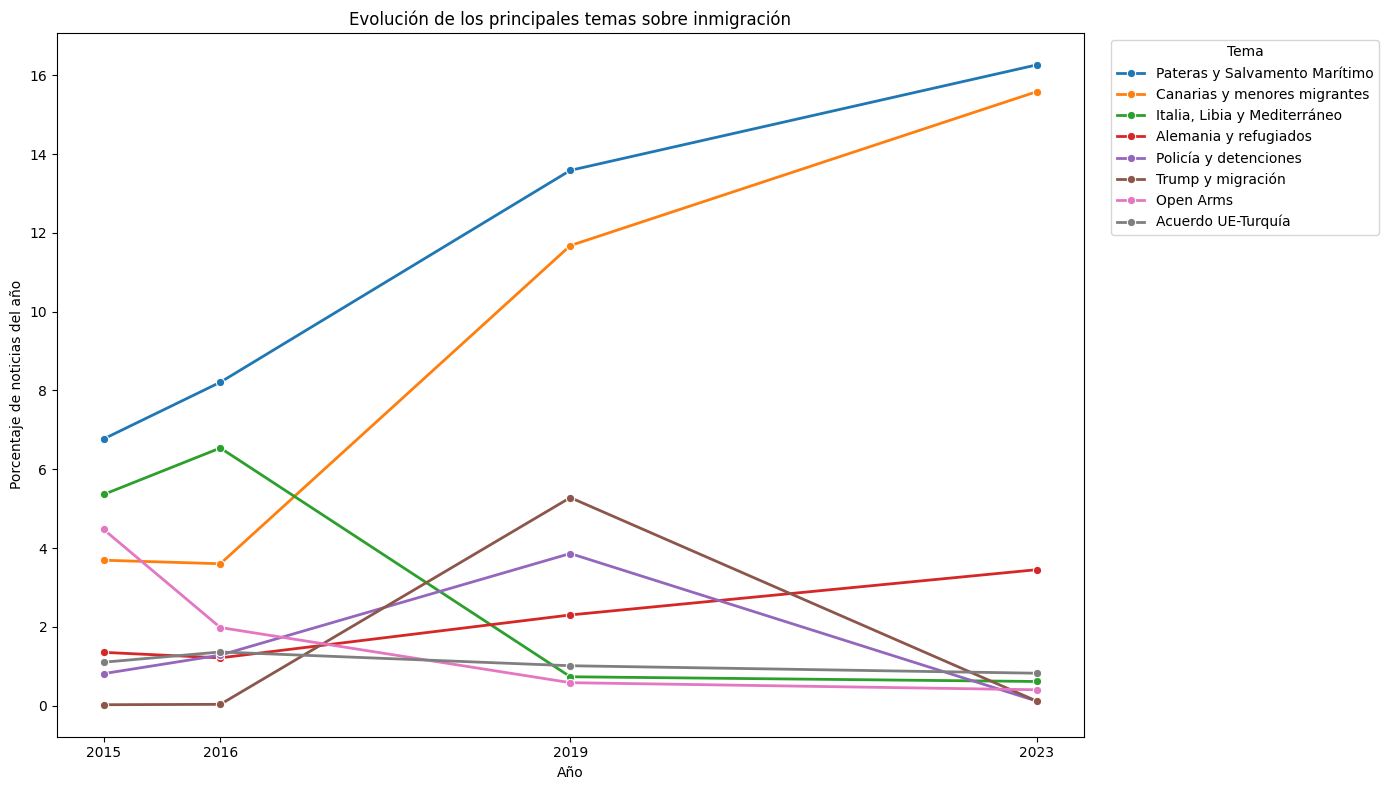

In [134]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=evolucion_temas,
    x="year_dataset",
    y="porcentaje_corpus",
    hue="etiqueta",
    marker="o",
    linewidth=2
)

plt.title(
    "Evolución de los principales temas sobre inmigración"
)
plt.xlabel("Año")
plt.ylabel("Porcentaje de noticias del año")
plt.xticks([2015, 2016, 2019, 2023])
plt.legend(
    title="Tema",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    RUTA_BERTOPIC_INMIGRACION_FIGURAS
    / "bertopic_inmigracion_evolucion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [135]:
temas_dinamicos_inmigracion = (
    modelo_final_inmigracion
    .topics_over_time(
        documentos_inmigracion,
        años_inmigracion,
        global_tuning=True,
        evolution_tuning=True
    )
)

display(temas_dinamicos_inmigracion.head(20))

4it [00:28,  7.08s/it]


,Topic,Words,Frequency,Timestamp
0,-1,"refugiados, europa, personas, países, 000",2830,2015
1,0,"patera, salvamento, marítimo, salvamento marít...",657,2015
2,1,"inmigrantes, inmigración, españa, personas, po...",358,2015
3,2,"merkel, alemania, refugiados, canciller, berlín",520,2015
4,3,"policía, agentes, detenido, policía nacional, ...",131,2015
5,4,"trump, republicano, donald trump, donald, obama",79,2015
6,5,"open, arms, open arms, misión, operación",2,2015
7,6,"refugiados, acogida, ayuntamiento, gobierno, a...",434,2015
8,7,"ceuta, inmigrantes, valla, vallado, marruecos",107,2015
9,8,"italia, renzi, italiano, inmigrantes, meloni",44,2015


In [136]:
display(
    temas_dinamicos_inmigracion[
        temas_dinamicos_inmigracion["Topic"] == 1
    ][
        [
            "Topic",
            "Timestamp",
            "Words",
            "Frequency"
        ]
    ]
)

,Topic,Timestamp,Words,Frequency
2,1,2015,"inmigrantes, inmigración, españa, personas, po...",358
86,1,2016,"inmigrantes, población, españa, inmigración, p...",412
173,1,2019,"vox, menores, inmigrantes, inmigración, españa",1786
263,1,2023,"canarias, migrantes, gobierno, menores, personas",3207


In [137]:
fig = (
    modelo_final_inmigracion
    .visualize_topics_over_time(
        temas_dinamicos_inmigracion,
        top_n_topics=8
    )
)

fig.show(renderer="browser")

In [139]:
ruta_html = (
    RUTA_BERTOPIC_INMIGRACION_FIGURAS
    / "bertopic_inmigracion_dinamico.html"
)

fig.write_html(ruta_html)

print(ruta_html)

C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\figures\prensa\bertopic\inmigracion\bertopic_inmigracion_dinamico.html


In [141]:
RUTA_MODELO_INMIGRACION = (
    RUTA_MODELOS
    / "inmigracion"
)

modelo_final_inmigracion.save(
    RUTA_MODELO_INMIGRACION,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=True
)

print(RUTA_MODELO_INMIGRACION)

C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\modelos\inmigracion


In [142]:
# Asignación de temas por noticia
documentos_con_tema.to_csv(
    RUTA_BERTOPIC_INMIGRACION_TABLAS
    / "bertopic_inmigracion_documentos.csv",
    index=False,
    encoding="utf-8-sig"
)

# Evolución anual normalizada
temas_por_año.to_csv(
    RUTA_BERTOPIC_INMIGRACION_TABLAS
    / "bertopic_inmigracion_por_anio.csv",
    index=False,
    encoding="utf-8-sig"
)

# Representaciones dinámicas
temas_dinamicos_inmigracion.to_csv(
    RUTA_BERTOPIC_INMIGRACION_TABLAS
    / "bertopic_inmigracion_dinamico.csv",
    index=False,
    encoding="utf-8-sig"
)

# Información general de los temas
info_final_inmigracion.to_csv(
    RUTA_BERTOPIC_INMIGRACION_TABLAS
    / "bertopic_inmigracion_temas.csv",
    index=False,
    encoding="utf-8-sig"
)

In [143]:
archivos_tablas = [
    "bertopic_inmigracion_documentos.csv",
    "bertopic_inmigracion_por_anio.csv",
    "bertopic_inmigracion_dinamico.csv",
    "bertopic_inmigracion_temas.csv"
]

print("TABLAS:")

for nombre in archivos_tablas:
    ruta = (
        RUTA_BERTOPIC_INMIGRACION_TABLAS
        / nombre
    )

    print(nombre, "→", ruta.exists())


archivo_html = (
    RUTA_BERTOPIC_INMIGRACION_FIGURAS
    / "bertopic_inmigracion_dinamico.html"
)

print("\nVISUALIZACIÓN:")
print(
    archivo_html.name,
    "→",
    archivo_html.exists()
)


print("\nMODELO:")
print(
    RUTA_MODELO_INMIGRACION,
    "→",
    RUTA_MODELO_INMIGRACION.exists()
)

TABLAS:
bertopic_inmigracion_documentos.csv → True
bertopic_inmigracion_por_anio.csv → True
bertopic_inmigracion_dinamico.csv → True
bertopic_inmigracion_temas.csv → True

VISUALIZACIÓN:
bertopic_inmigracion_dinamico.html → True

MODELO:
C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\modelos\inmigracion → True


BerTopic LIGTBI

In [144]:
df_bertopic_lgtb = (
    df_lgtb[
        [
            "title",
            "texto_limpio",
            "year_dataset"
        ]
    ]
    .dropna(subset=["texto_limpio"])
    .copy()
)

df_bertopic_lgtb["documento"] = (
    df_bertopic_lgtb["title"]
    .fillna("")
    .astype(str)
    + ". "
    + df_bertopic_lgtb["texto_limpio"]
    .fillna("")
    .astype(str)
)

df_bertopic_lgtb = (
    df_bertopic_lgtb[
        df_bertopic_lgtb["documento"].str.len() >= 50
    ]
    .reset_index(drop=True)
)

documentos_lgtb = (
    df_bertopic_lgtb["documento"]
    .tolist()
)

años_lgtb = (
    df_bertopic_lgtb["year_dataset"]
    .astype(int)
    .tolist()
)

print("Documentos:", len(documentos_lgtb))

display(
    df_bertopic_lgtb["year_dataset"]
    .value_counts()
    .sort_index()
)

Documentos: 18163


year_dataset
2015    1900
2016    2996
2019    5712
2023    7555
Name: count, dtype: int64

In [145]:
embeddings_lgtb = modelo_embeddings.encode(
    documentos_lgtb,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches: 100%|██████████| 568/568 [03:47<00:00,  2.50it/s]


In [146]:
vectorizador_bertopic_lgtb = CountVectorizer(
    stop_words=list(stopwords_total),
    ngram_range=(1, 2),
    min_df=5
)

modelo_umap_lgtb = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan_lgtb = HDBSCAN(
    min_cluster_size=50,
    min_samples=5,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

modelo_bertopic_lgtb = BERTopic(
    embedding_model=modelo_embeddings,
    vectorizer_model=vectorizador_bertopic_lgtb,
    umap_model=modelo_umap_lgtb,
    hdbscan_model=modelo_hdbscan_lgtb,
    language="multilingual",
    calculate_probabilities=False,
    low_memory=True,
    verbose=True
)

In [147]:
temas_lgtb, probabilidades_lgtb = (
    modelo_bertopic_lgtb.fit_transform(
        documentos_lgtb,
        embeddings_lgtb
    )
)

2026-07-24 22:32:48,665 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 22:33:00,373 - BERTopic - Dimensionality - Completed ✓
2026-07-24 22:33:00,374 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 22:33:01,873 - BERTopic - Cluster - Completed ✓
2026-07-24 22:33:01,876 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 22:33:08,694 - BERTopic - Representation - Completed ✓


In [148]:
info_temas_lgtb = (
    modelo_bertopic_lgtb
    .get_topic_info()
)

display(info_temas_lgtb.head(30))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7701,-1_lgtbi_personas_derechos_colectivo,"[lgtbi, personas, derechos, colectivo, orgullo...",[Un Orgullo más reivindicativo y político sale...
1,0,817,0_lgtbi_igualdad_ley_diversidad,"[lgtbi, igualdad, ley, diversidad, personas, c...","[PP, CS y Vox frenan la ley LGTBI propuesta po..."
2,1,490,1_fútbol_jankto_futbolista_jugador,"[fútbol, jankto, futbolista, jugador, jakub, g...","[El checo Jantko, primer futbolista de la Liga..."
3,2,354,2_orgullo_00_orgullo gay_20,"[orgullo, 00, orgullo gay, 20, madrid, gay, 20...",[Programación del Orgullo Gay de Madrid 2019: ...
4,3,348,3_homosexualidad_cañizares_alcalá_obispado,"[homosexualidad, cañizares, alcalá, obispado, ...",[Aluvión de denuncias contra los cursos para '...
5,4,345,4_orgullo_lgtbi_orgullo lgtbi_lgtbiq,"[orgullo, lgtbi, orgullo lgtbi, lgtbiq, día, j...",[Santander celebra este sábado el Día del Orgu...
6,5,343,5_acusado_víctima_hechos_prisión,"[acusado, víctima, hechos, prisión, delito, cá...",[Confirmada una sentencia de 30 meses de cárce...
7,6,293,6_película_personajes_serie_cine,"[película, personajes, serie, cine, personaje,...",[La próxima película de Amenábar será de temát...
8,7,281,7_bandera_bandera lgtbi_ayuntamiento_vox,"[bandera, bandera lgtbi, ayuntamiento, vox, pp...",[Vox denuncia a una alcaldesa socialista de Gr...
9,8,234,8_rusia_propaganda_ruso_rusa,"[rusia, propaganda, ruso, rusa, putin, movimie...",[El Supremo prohíbe el movimiento LGTB en Rusi...


In [149]:
resumen_lgtb = resumen_modelo(
    "LGTBI: cluster=50, samples=5",
    temas_lgtb,
    modelo_bertopic_lgtb
)

display(pd.DataFrame([resumen_lgtb]))

,modelo,documentos,outliers,porcentaje_outliers,temas_validos
0,"LGTBI: cluster=50, samples=5",18163,7701,42.4,84


In [150]:
modelo_umap_lgtb_v2 = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

modelo_hdbscan_lgtb_v2 = HDBSCAN(
    min_cluster_size=50,
    min_samples=2,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

modelo_bertopic_lgtb_v2 = BERTopic(
    embedding_model=modelo_embeddings,
    vectorizer_model=vectorizador_bertopic_lgtb,
    umap_model=modelo_umap_lgtb_v2,
    hdbscan_model=modelo_hdbscan_lgtb_v2,
    language="multilingual",
    calculate_probabilities=False,
    low_memory=True,
    verbose=True
)

In [151]:
temas_lgtb_v2, probabilidades_lgtb_v2 = (
    modelo_bertopic_lgtb_v2.fit_transform(
        documentos_lgtb,
        embeddings_lgtb
    )
)

2026-07-24 22:33:12,129 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-24 22:33:23,845 - BERTopic - Dimensionality - Completed ✓
2026-07-24 22:33:23,846 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-24 22:33:24,154 - BERTopic - Cluster - Completed ✓
2026-07-24 22:33:24,157 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-24 22:33:30,868 - BERTopic - Representation - Completed ✓


In [152]:
comparacion_lgtb = pd.DataFrame([
    resumen_modelo(
        "LGTBI V1: cluster=50, samples=5",
        temas_lgtb,
        modelo_bertopic_lgtb
    ),
    resumen_modelo(
        "LGTBI V2: cluster=50, samples=2",
        temas_lgtb_v2,
        modelo_bertopic_lgtb_v2
    )
])

display(comparacion_lgtb)

,modelo,documentos,outliers,porcentaje_outliers,temas_validos
0,"LGTBI V1: cluster=50, samples=5",18163,7701,42.40,84
1,"LGTBI V2: cluster=50, samples=2",18163,7813,43.02,92


In [153]:
info_temas_lgtb_v2 = (
    modelo_bertopic_lgtb_v2
    .get_topic_info()
)

display(info_temas_lgtb_v2.head(30))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7813,-1_lgtbi_personas_derechos_colectivo,"[lgtbi, personas, derechos, colectivo, si, org...",[Arranca el Orgullo LGTBI más reivindicativo d...
1,0,410,0_lgtbi_diversidad_igualdad_personas,"[lgtbi, diversidad, igualdad, personas, colect...",[La Junta reivindica una Andalucía libre de LG...
2,1,343,1_acusado_víctima_hechos_prisión,"[acusado, víctima, hechos, prisión, delito, cá...",[Confirmada una sentencia de 30 meses de cárce...
3,2,323,2_orgullo_orgullo lgtbi_lgtbi_lgtbiq,"[orgullo, orgullo lgtbi, lgtbi, lgtbiq, junio,...",[El Ayuntamiento celebra este sábado el Día de...
4,3,307,3_00_orgullo_20_orgullo gay,"[00, orgullo, 20, orgullo gay, madrid, actuaci...","[Orgullo Gay 2019 en Madrid: programa, calenda..."
5,4,303,4_cañizares_alcalá_homosexualidad_obispado,"[cañizares, alcalá, homosexualidad, obispado, ...",[El obispado de Alcalá defiende sus polémicos ...
6,5,298,5_fútbol_deporte_jugador_árbitro,"[fútbol, deporte, jugador, árbitro, tomillero,...","[La homosexualidad, el eterno tabú que impera ..."
7,6,237,6_bandera_bandera lgtbi_ayuntamiento_vox,"[bandera, bandera lgtbi, ayuntamiento, vox, lg...",[Vox denuncia a una alcaldesa socialista de Gr...
8,7,234,7_rusia_propaganda_ruso_rusa,"[rusia, propaganda, ruso, rusa, putin, movimie...",[El Supremo prohíbe el movimiento LGTB en Rusi...
9,8,226,8_serie_personajes_personaje_actriz,"[serie, personajes, personaje, actriz, actor, ...",[El cine ignora la bisexualidad: 30 personajes...


In [154]:
modelo_final_lgtb = modelo_bertopic_lgtb
temas_finales_lgtb = temas_lgtb
info_final_lgtb = info_temas_lgtb

In [155]:
stopwords_bertopic_lgtb = set(stopwords_total).union({
    "strong"
})

vectorizador_lgtb_limpio = CountVectorizer(
    stop_words=list(stopwords_bertopic_lgtb),
    ngram_range=(1, 2),
    min_df=5
)

modelo_final_lgtb.update_topics(
    documentos_lgtb,
    vectorizer_model=vectorizador_lgtb_limpio
)

info_final_lgtb = (
    modelo_final_lgtb
    .get_topic_info()
)

display(info_final_lgtb.head(30))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7701,-1_lgtbi_personas_derechos_colectivo,"[lgtbi, personas, derechos, colectivo, orgullo...",[Un Orgullo más reivindicativo y político sale...
1,0,817,0_lgtbi_igualdad_ley_diversidad,"[lgtbi, igualdad, ley, diversidad, personas, c...","[PP, CS y Vox frenan la ley LGTBI propuesta po..."
2,1,490,1_fútbol_jankto_futbolista_jugador,"[fútbol, jankto, futbolista, jugador, jakub, g...","[El checo Jantko, primer futbolista de la Liga..."
3,2,354,2_orgullo_00_orgullo gay_20,"[orgullo, 00, orgullo gay, 20, madrid, gay, 20...",[Programación del Orgullo Gay de Madrid 2019: ...
4,3,348,3_homosexualidad_cañizares_alcalá_obispado,"[homosexualidad, cañizares, alcalá, obispado, ...",[Aluvión de denuncias contra los cursos para '...
5,4,345,4_orgullo_lgtbi_orgullo lgtbi_lgtbiq,"[orgullo, lgtbi, orgullo lgtbi, lgtbiq, día, j...",[Santander celebra este sábado el Día del Orgu...
6,5,343,5_acusado_víctima_hechos_prisión,"[acusado, víctima, hechos, prisión, delito, cá...",[Confirmada una sentencia de 30 meses de cárce...
7,6,293,6_película_personajes_serie_cine,"[película, personajes, serie, cine, personaje,...",[La próxima película de Amenábar será de temát...
8,7,281,7_bandera_bandera lgtbi_ayuntamiento_vox,"[bandera, bandera lgtbi, ayuntamiento, vox, pp...",[Vox denuncia a una alcaldesa socialista de Gr...
9,8,234,8_rusia_propaganda_ruso_rusa,"[rusia, propaganda, ruso, rusa, putin, movimie...",[El Supremo prohíbe el movimiento LGTB en Rusi...


In [156]:
documentos_con_tema_lgtb = (
    modelo_final_lgtb
    .get_document_info(documentos_lgtb)
)

documentos_con_tema_lgtb["year_dataset"] = (
    df_bertopic_lgtb["year_dataset"]
    .to_numpy()
)

documentos_con_tema_lgtb["title"] = (
    df_bertopic_lgtb["title"]
    .to_numpy()
)

In [157]:
outliers_lgtb_por_año = (
    documentos_con_tema_lgtb
    .assign(
        es_outlier=lambda datos: datos["Topic"].eq(-1)
    )
    .groupby("year_dataset")
    .agg(
        total_documentos=("Topic", "size"),
        outliers=("es_outlier", "sum")
    )
    .reset_index()
)

outliers_lgtb_por_año["porcentaje_outliers"] = (
    outliers_lgtb_por_año["outliers"]
    / outliers_lgtb_por_año["total_documentos"]
    * 100
).round(2)

display(outliers_lgtb_por_año)

,year_dataset,total_documentos,outliers,porcentaje_outliers
0,2015,1900,481,25.32
1,2016,2996,1037,34.61
2,2019,5712,2430,42.54
3,2023,7555,3753,49.68


In [158]:
totales_lgtb_anuales = (
    documentos_con_tema_lgtb
    .groupby("year_dataset")
    .size()
    .rename("total_documentos_anio")
)

temas_lgtb_por_año = (
    documentos_con_tema_lgtb[
        documentos_con_tema_lgtb["Topic"] != -1
    ]
    .groupby(
        [
            "year_dataset",
            "Topic",
            "Name"
        ]
    )
    .size()
    .reset_index(name="documentos")
)

temas_lgtb_por_año["total_documentos_anio"] = (
    temas_lgtb_por_año["year_dataset"]
    .map(totales_lgtb_anuales)
)

temas_lgtb_por_año["porcentaje_corpus"] = (
    temas_lgtb_por_año["documentos"]
    / temas_lgtb_por_año["total_documentos_anio"]
    * 100
).round(2)

In [159]:
top_temas_lgtb_por_año = (
    temas_lgtb_por_año
    .sort_values(
        ["year_dataset", "porcentaje_corpus"],
        ascending=[True, False]
    )
    .groupby("year_dataset")
    .head(10)
    .reset_index(drop=True)
)

display(top_temas_lgtb_por_año)

,year_dataset,Topic,Name,documentos,total_documentos_anio,porcentaje_corpus
0,2015,21,21_matrimonio_supremo_florida_tribunal,88,1900,4.63
1,2015,11,11_matrimonio_mismo sexo_parejas_sexo,87,1900,4.58
2,2015,25,25_padrino_salinas_iglesia_obispado,82,1900,4.32
3,2015,0,0_lgtbi_igualdad_ley_diversidad,71,1900,3.74
4,2015,32,32_iglesia_vaticano_papa_sacerdote,61,1900,3.21
5,2015,29,29_sangre_donar_donar sangre_homosexuales,60,1900,3.16
6,2015,2,2_orgullo_00_orgullo gay_20,52,1900,2.74
7,2015,16,16_bandera_ayuntamiento_orgullo_día,50,1900,2.63
8,2015,63,63_irlanda_matrimonio_referéndum_dublín,50,1900,2.63
9,2015,6,6_película_personajes_serie_cine,44,1900,2.32


In [160]:
stopwords_bertopic_lgtb.update({
    "si",
    "strong"
})

vectorizador_lgtb_final = CountVectorizer(
    stop_words=list(stopwords_bertopic_lgtb),
    ngram_range=(1, 2),
    min_df=5,
    token_pattern=r"(?u)\b[a-záéíóúüñ][a-záéíóúüñ]+\b"
)

modelo_final_lgtb.update_topics(
    documentos_lgtb,
    vectorizer_model=vectorizador_lgtb_final
)

info_final_lgtb = (
    modelo_final_lgtb
    .get_topic_info()
)

display(info_final_lgtb.head(20))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,7701,-1_lgtbi_personas_derechos_colectivo,"[lgtbi, personas, derechos, colectivo, orgullo...",[Un Orgullo más reivindicativo y político sale...
1,0,817,0_lgtbi_igualdad_ley_diversidad,"[lgtbi, igualdad, ley, diversidad, personas, c...","[PP, CS y Vox frenan la ley LGTBI propuesta po..."
2,1,490,1_fútbol_jankto_futbolista_jugador,"[fútbol, jankto, futbolista, jugador, jakub, g...","[El checo Jantko, primer futbolista de la Liga..."
3,2,354,2_orgullo_orgullo gay_madrid_gay,"[orgullo, orgullo gay, madrid, gay, plaza, act...",[Programación del Orgullo Gay de Madrid 2019: ...
4,3,348,3_homosexualidad_cañizares_alcalá_obispado,"[homosexualidad, cañizares, alcalá, obispado, ...",[Aluvión de denuncias contra los cursos para '...
5,4,345,4_orgullo_lgtbi_orgullo lgtbi_lgtbiq,"[orgullo, lgtbi, orgullo lgtbi, lgtbiq, día, j...",[Santander celebra este sábado el Día del Orgu...
6,5,343,5_acusado_víctima_hechos_prisión,"[acusado, víctima, hechos, prisión, delito, cá...",[Confirmada una sentencia de 30 meses de cárce...
7,6,293,6_película_personajes_serie_cine,"[película, personajes, serie, cine, personaje,...",[La próxima película de Amenábar será de temát...
8,7,281,7_bandera_bandera lgtbi_ayuntamiento_vox,"[bandera, bandera lgtbi, ayuntamiento, vox, pp...",[Vox denuncia a una alcaldesa socialista de Gr...
9,8,234,8_rusia_propaganda_ruso_rusa,"[rusia, propaganda, ruso, rusa, putin, movimie...",[El Supremo prohíbe el movimiento LGTB en Rusi...


In [161]:
etiquetas_lgtb = {
    0: "Derechos, igualdad y diversidad",
    1: "Diversidad sexual en el fútbol",
    2: "Orgullo gay y celebraciones",
    3: "Iglesia y homosexualidad",
    4: "Orgullo y colectivo LGTBI",
    5: "Casos judiciales y víctimas",
    6: "Representación en cine y series",
    7: "Bandera LGTBI y ayuntamientos",
    8: "Políticas anti-LGTBI en Rusia",
    9: "Bisexualidad y mujeres",
    10: "Policía y detenciones",
    11: "Matrimonio entre personas del mismo sexo",
    12: "Atentado de Orlando",
    13: "Salud y personas trans",
    14: "Delitos de odio y agresiones",
    16: "Orgullo, banderas e instituciones",
    21: "Matrimonio igualitario en Estados Unidos",
    22: "Matrimonio igualitario en Taiwán",
    24: "Personas trans en el deporte",
    25: "Iglesia y controversias religiosas",
    26: "Cambio de nombre e infancia trans",
    29: "Donación de sangre y homosexualidad",
    32: "Iglesia y Vaticano",
    63: "Referéndum de matrimonio en Irlanda"
}

temas_lgtb_por_año["etiqueta"] = (
    temas_lgtb_por_año["Topic"]
    .map(etiquetas_lgtb)
    .fillna(temas_lgtb_por_año["Name"])
)

In [162]:
temas_principales_lgtb = (
    temas_lgtb_por_año
    .groupby("Topic")["documentos"]
    .sum()
    .nlargest(8)
    .index
)

evolucion_lgtb = (
    temas_lgtb_por_año[
        temas_lgtb_por_año["Topic"]
        .isin(temas_principales_lgtb)
    ]
    .copy()
)

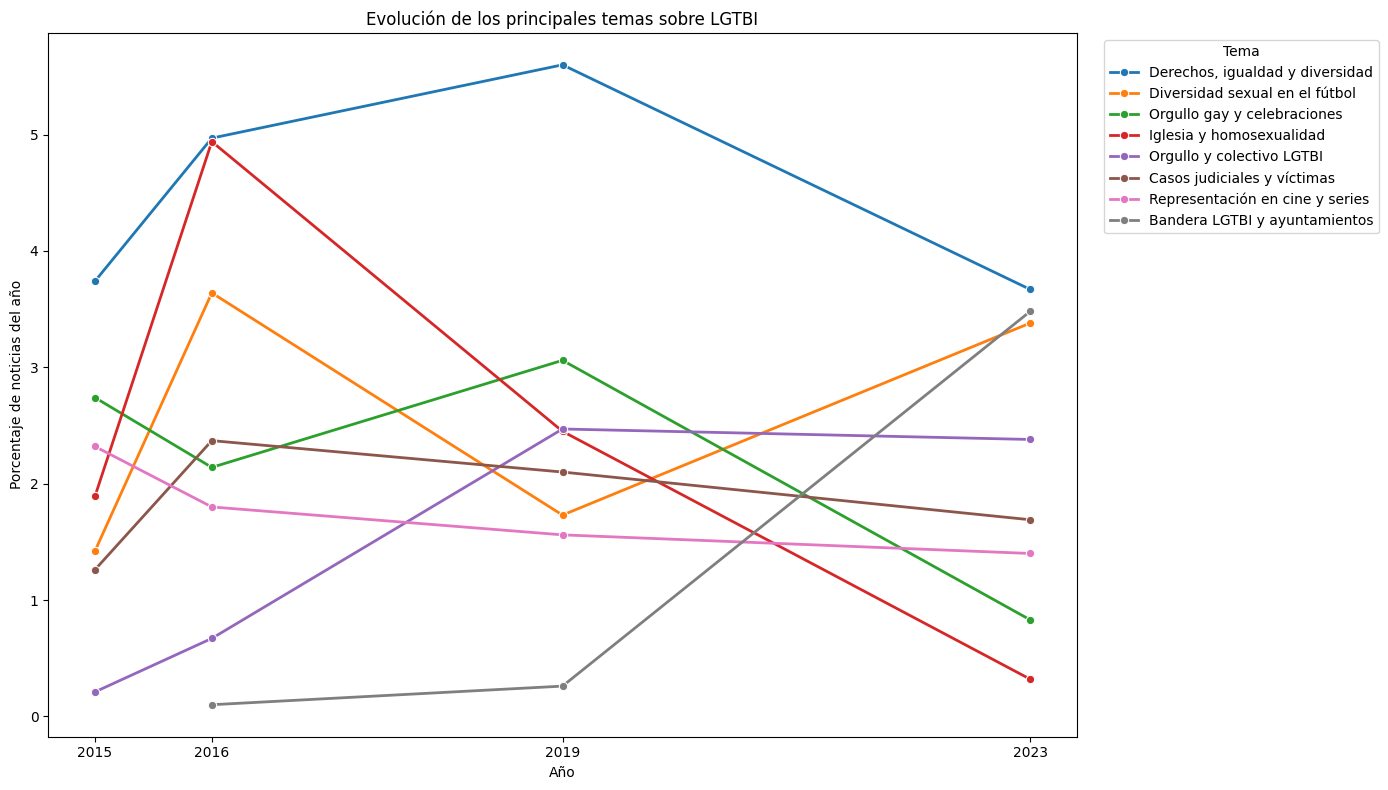

In [164]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=evolucion_lgtb,
    x="year_dataset",
    y="porcentaje_corpus",
    hue="etiqueta",
    marker="o",
    linewidth=2
)

plt.title(
    "Evolución de los principales temas sobre LGTBI"
)
plt.xlabel("Año")
plt.ylabel("Porcentaje de noticias del año")
plt.xticks([2015, 2016, 2019, 2023])

plt.legend(
    title="Tema",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    RUTA_BERTOPIC_LGTBI_FIGURAS
    / "bertopic_lgtbi_evolucion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [165]:
rejilla_lgtb = (
    pd.MultiIndex.from_product(
        [
            [2015, 2016, 2019, 2023],
            temas_principales_lgtb
        ],
        names=["year_dataset", "Topic"]
    )
    .to_frame(index=False)
)

evolucion_lgtb_completa = (
    rejilla_lgtb
    .merge(
        evolucion_lgtb[
            [
                "year_dataset",
                "Topic",
                "documentos",
                "porcentaje_corpus"
            ]
        ],
        on=["year_dataset", "Topic"],
        how="left"
    )
)

evolucion_lgtb_completa[
    ["documentos", "porcentaje_corpus"]
] = (
    evolucion_lgtb_completa[
        ["documentos", "porcentaje_corpus"]
    ]
    .fillna(0)
)

evolucion_lgtb_completa["etiqueta"] = (
    evolucion_lgtb_completa["Topic"]
    .map(etiquetas_lgtb)
)


In [167]:
temas_dinamicos_lgtb = (
    modelo_final_lgtb
    .topics_over_time(
        documentos_lgtb,
        años_lgtb,
        global_tuning=True,
        evolution_tuning=True
    )
)

display(temas_dinamicos_lgtb.head(20))

4it [00:07,  1.87s/it]


,Topic,Words,Frequency,Timestamp
0,-1,"gay, personas, homosexuales, derechos, ley",481,2015
1,0,"extremadura, ley, igualdad, colectivo, sexual",71,2015
2,1,"kennedy, fútbol, nba, árbitro, jugador",27,2015
3,2,"orgullo, orgullo gay, madrid, gay, plaza",52,2015
4,3,"web, parroquia, homosexualidad, sanar homosexu...",36,2015
5,4,"orgullo, alcoy, orgullo lgtbi, plasencia, lgtbi",4,2015
6,5,"víctima, prisión, hechos, acusado, audiencia",24,2015
7,6,"actor, gay, personaje, película, movistar",44,2015
8,8,"rusia, photo, putin, ruso, propaganda",37,2015
9,9,"mujeres, bisexuales, homosexual, facebook, hom...",32,2015


In [168]:
fig_lgtb = (
    modelo_final_lgtb
    .visualize_topics_over_time(
        temas_dinamicos_lgtb,
        top_n_topics=8
    )
)

fig_lgtb.show(renderer="browser")

In [170]:
RUTA_HTML_LGTBI = (
    RUTA_BERTOPIC_LGTBI_FIGURAS
    / "bertopic_lgtbi_dinamico.html"
)

fig_lgtb.write_html(
    RUTA_HTML_LGTBI
)

print(RUTA_HTML_LGTBI)

C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\figures\prensa\bertopic\lgtbi\bertopic_lgtbi_dinamico.html


In [171]:
# Asignación de temas por noticia
documentos_con_tema_lgtb.to_csv(
    RUTA_BERTOPIC_LGTBI_TABLAS
    / "bertopic_lgtbi_documentos.csv",
    index=False,
    encoding="utf-8-sig"
)

# Evolución anual
temas_lgtb_por_año.to_csv(
    RUTA_BERTOPIC_LGTBI_TABLAS
    / "bertopic_lgtbi_por_anio.csv",
    index=False,
    encoding="utf-8-sig"
)

# Representaciones dinámicas
temas_dinamicos_lgtb.to_csv(
    RUTA_BERTOPIC_LGTBI_TABLAS
    / "bertopic_lgtbi_dinamico.csv",
    index=False,
    encoding="utf-8-sig"
)

# Información general de los temas
info_final_lgtb.to_csv(
    RUTA_BERTOPIC_LGTBI_TABLAS
    / "bertopic_lgtbi_temas.csv",
    index=False,
    encoding="utf-8-sig"
)

# Modelo BERTopic LGTBI
RUTA_MODELO_LGTBI = (
    RUTA_MODELOS
    / "lgtbi"
)

modelo_final_lgtb.save(
    RUTA_MODELO_LGTBI,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model=True
)

print("Tablas:", RUTA_BERTOPIC_LGTBI_TABLAS)
print("Modelo:", RUTA_MODELO_LGTBI)

Tablas: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\prensa\bertopic\lgtbi
Modelo: C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\02_processed\modelos\lgtbi


In [172]:
def incorporar_bertopic(
    df_corpus,
    documentos_entrenamiento,
    temas,
    modelo
):
    base = (
        df_corpus[
            [
                "title",
                "texto_limpio",
                "year_dataset"
            ]
        ]
        .dropna(subset=["texto_limpio"])
        .copy()
    )

    base["documento"] = (
        base["title"]
        .fillna("")
        .astype(str)
        + ". "
        + base["texto_limpio"]
        .fillna("")
        .astype(str)
    )

    base = base[
        base["documento"].str.len() >= 50
    ].copy()

    # Verificación esencial: mismo orden usado por BERTopic
    assert (
        base["documento"].tolist()
        == documentos_entrenamiento
    ), "El orden de los documentos no coincide con BERTopic"

    salida = df_corpus.copy()

    salida["bertopic_id"] = pd.NA
    salida["bertopic_nombre"] = pd.NA

    temas_array = np.asarray(temas)

    nombres = (
        modelo.get_topic_info()
        .set_index("Topic")["Name"]
        .to_dict()
    )

    salida.loc[
        base.index,
        "bertopic_id"
    ] = temas_array

    salida.loc[
        base.index,
        "bertopic_nombre"
    ] = [
        nombres.get(tema, "Sin tema")
        for tema in temas_array
    ]

    return salida

In [173]:
df_inmigracion_final = incorporar_bertopic(
    df_inmigracion,
    documentos_inmigracion,
    temas_finales_inmigracion,
    modelo_final_inmigracion
)

df_lgtb_final = incorporar_bertopic(
    df_lgtb,
    documentos_lgtb,
    temas_finales_lgtb,
    modelo_final_lgtb
)

In [174]:
print(
    "Sentimiento inmigración:",
    "sentimiento" in df_inmigracion_final.columns
)

print(
    "Sentimiento LGTBI:",
    "sentimiento" in df_lgtb_final.columns
)

Sentimiento inmigración: True
Sentimiento LGTBI: True


In [175]:
# Completar la categoría que no corresponde a cada corpus
df_inmigracion_final["nivel_lgtbifobia"] = "sin_mencion"
df_lgtb_final["nivel_xenofobia"] = "sin_mencion"

# Unificar
prensa_nlp_final = pd.concat(
    [
        df_inmigracion_final,
        df_lgtb_final
    ],
    ignore_index=True
)

# Estandarizar nombres para la comparación
prensa_nlp_final = prensa_nlp_final.rename(
    columns={
        "year_dataset": "anio"
    }
)

prensa_nlp_final["tema"] = (
    prensa_nlp_final["tema"]
    .replace({
        "inmigracion": "Inmigración",
        "lgtb": "LGTBI"
    })
)

prensa_nlp_final["origen"] = "Prensa"

In [176]:
columnas_anio = prensa_nlp_final.loc[
    :,
    prensa_nlp_final.columns == "anio"
]

anio_unico = (
    columnas_anio
    .bfill(axis=1)
    .iloc[:, 0]
)

prensa_nlp_final = prensa_nlp_final.loc[
    :,
    prensa_nlp_final.columns != "anio"
].copy()

prensa_nlp_final["anio"] = (
    pd.to_numeric(
        anio_unico,
        errors="coerce"
    )
    .astype("Int64")
)

In [177]:
print(
    prensa_nlp_final.columns[
        prensa_nlp_final.columns.duplicated()
    ].tolist()
)

[]


In [178]:
columnas_nlp = [
    "anio",
    "origen",
    "tema",
    "sentimiento",
    "nivel_xenofobia",
    "nivel_lgtbifobia",
    "bertopic_id",
    "bertopic_nombre"
]

display(
    prensa_nlp_final[columnas_nlp].head()
)

print("Dimensiones:", prensa_nlp_final.shape)

resumen_anual = (
    prensa_nlp_final
    .groupby(
        ["anio", "tema"],
        dropna=False
    )
    .size()
    .reset_index(name="documentos")
    .sort_values(["anio", "tema"])
)

display(resumen_anual)

,anio,origen,tema,sentimiento,nivel_xenofobia,nivel_lgtbifobia,bertopic_id,bertopic_nombre
0,2015,Prensa,Inmigración,Negativo,neutro,sin_mencion,3,3_policía_detenido_policía nacional_agentes
1,2015,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion,-1,-1_refugiados_personas_migrantes_país
2,2015,Prensa,Inmigración,Neutral,neutro,sin_mencion,1,1_canarias_gobierno_migrantes_menores
3,2015,Prensa,Inmigración,Negativo,marco_conflictivo,sin_mencion,40,40_libia_mediterráneo_naufragio_costa libia
4,2015,Prensa,Inmigración,Negativo,hostilidad_explicita,sin_mencion,18,18_ue_europea_países_migración


Dimensiones: (75151, 19)


,anio,tema,documentos
0,2015,Inmigración,9701
1,2015,LGTBI,1900
2,2016,Inmigración,11429
3,2016,LGTBI,2996
4,2019,Inmigración,15285
5,2019,LGTBI,5712
6,2023,Inmigración,20573
7,2023,LGTBI,7555


In [179]:
RUTA_PRENSA_NLP_FINAL = (
    RUTA_FINAL_PRENSA
    / "prensa_nlp_final.csv"
)

prensa_nlp_final.to_csv(
    RUTA_PRENSA_NLP_FINAL,
    index=False,
    encoding="utf-8-sig"
)

print(RUTA_PRENSA_NLP_FINAL)

C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\03_final\prensa\prensa_nlp_final.csv


In [180]:
from pathlib import Path

ruta_exportada = Path(RUTA_PRENSA_NLP_FINAL)

print("Existe:", ruta_exportada.exists())
print(
    "Tamaño MB:",
    round(ruta_exportada.stat().st_size / 1_000_000, 2)
)

prensa_comprobacion = pd.read_csv(
    ruta_exportada,
    low_memory=False
)

print("Dimensiones:", prensa_comprobacion.shape)
display(prensa_comprobacion.head())

Existe: True
Tamaño MB: 497.43
Dimensiones: (75151, 19)


,id,publish_date,media_name,media_url,title,url,language,mes,texto,tema,texto_limpio,nivel_xenofobia,nivel_lgtbifobia,fecha,sentimiento,bertopic_id,bertopic_nombre,origen,anio
0,50859f6f441e40d325df5f31d22369451c2bc5a02fd23b...,2015-02-11,diariojaen.es,diariojaen.es,Golpe a la inmigración clandestina,https://www.diariojaen.es/historico/golpe-a-la...,es,2015-02,Golpe a la inmigración clandestina\nContra los...,Inmigración,golpe a la inmigración clandestina contra los ...,neutro,sin_mencion,2015-02-11,Negativo,3,3_policía_detenido_policía nacional_agentes,Prensa,2015
1,73033c3fd29d8952fc066c6c9295ad46dfcb7621568fad...,2015-01-09,diariojaen.es,diariojaen.es,Los Reyes Magos van en patera,https://www.diariojaen.es/historico/los-reyes-...,es,2015-01,Los Reyes Magos van en patera\nAquellos vetust...,Inmigración,los reyes magos van en patera aquellos vetusto...,marco_conflictivo,sin_mencion,2015-01-09,Negativo,-1,-1_refugiados_personas_migrantes_país,Prensa,2015
2,c8a983e636022993dd991c2d7e5ba58f378944c76aa3a7...,2015-02-16,diariojaen.es,diariojaen.es,Cae de manera drástica la contratación de inmi...,https://www.diariojaen.es/historico/cae-de-man...,es,2015-02,Cae de manera drástica la contratación de inmi...,Inmigración,cae de manera drástica la contratación de inmi...,neutro,sin_mencion,2015-02-16,Neutral,1,1_canarias_gobierno_migrantes_menores,Prensa,2015
3,d25f31e8b090909033d70dfaa3a6abc224781f4783a16c...,2015-04-22,diariojaen.es,diariojaen.es,La tragedia de la inmigración,https://www.diariojaen.es/historico/la-tragedi...,es,2015-04,La tragedia de la inmigración\nEl reciente nau...,Inmigración,la tragedia de la inmigración el reciente nauf...,marco_conflictivo,sin_mencion,2015-04-22,Negativo,40,40_libia_mediterráneo_naufragio_costa libia,Prensa,2015
4,da0cd33371a533d51bbf141da1d3bb7606a1088a50fc0f...,2015-03-12,diariojaen.es,diariojaen.es,Hablando de inmigración,https://www.diariojaen.es/historico/hablando-d...,es,2015-03,Hablando de inmigración\nHace ya muchos siglos...,Inmigración,"hablando de inmigración hace ya muchos siglos,...",hostilidad_explicita,sin_mencion,2015-03-12,Negativo,18,18_ue_europea_países_migración,Prensa,2015


Versión reducida

In [181]:
columnas_comparacion = [
    "anio",
    "origen",
    "tema",
    "sentimiento",
    "nivel_xenofobia",
    "nivel_lgtbifobia",
    "bertopic_id",
    "bertopic_nombre"
]

prensa_nlp_comparacion = (
    prensa_nlp_final[columnas_comparacion]
    .copy()
)

RUTA_PRENSA_COMPARACION = (
    RUTA_TABLAS_PRENSA
    / "prensa_nlp_comparacion.csv"
)

prensa_nlp_comparacion.to_csv(
    RUTA_PRENSA_COMPARACION,
    index=False,
    encoding="utf-8-sig"
)

print(RUTA_PRENSA_COMPARACION)

C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\prensa\prensa_nlp_comparacion.csv


In [182]:
print(prensa_nlp_comparacion.shape)
print(prensa_nlp_comparacion.isna().sum())

display(
    prensa_nlp_comparacion
    .groupby(["anio", "tema"])
    .size()
    .reset_index(name="documentos")
)

(75151, 8)
anio                0
origen              0
tema                0
sentimiento         0
nivel_xenofobia     0
nivel_lgtbifobia    0
bertopic_id         0
bertopic_nombre     0
dtype: int64


,anio,tema,documentos
0,2015,Inmigración,9701
1,2015,LGTBI,1900
2,2016,Inmigración,11429
3,2016,LGTBI,2996
4,2019,Inmigración,15285
5,2019,LGTBI,5712
6,2023,Inmigración,20573
7,2023,LGTBI,7555
